In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 26
day = 18

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

26 18
optimal travel lag is 11.761761761761768 cm based on kde of travel at max spatial information
optimal travel lag is 11.761761761761768 cm
firing rates are similar for cluster id 35, VR: 3.490781971784094, OF1: 4.095808531411458
firing rates are similar for cluster id 47, VR: 5.836836045334111, OF1: 5.4453567566098595
firing rates are similar for cluster id 52, VR: 5.229236894308267, OF1: 22.3126409814225
firing rates are similar for cluster id 54, VR: 4.93681246271866, OF1: 5.845835813014535
firing rates are similar for cluster id 56, VR: 49.03574847059803, OF1: 24.473076552233675
firing rates are similar for cluster id 62, VR: 7.628005049454132, OF1: 4.400305004049724
firing rates are similar for cluster id 65, VR: 1.95652475481016, OF1: 2.434316908972224
firing rates are similar for cluster id 67, VR: 23.6425430382732, OF1: 21.43142157011882
firing rates are similar for cluster id 71, VR: 2.348273613827736, OF1: 7.246685074363949
firing rates are similar for cluster id 73, VR: 

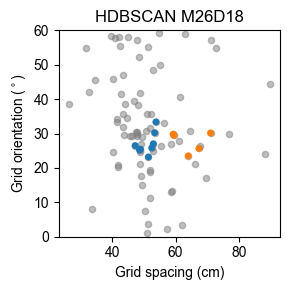

for module 0, there are 8 cells with average spacing 51.11118491267649
for module 1, there are 5 cells with average spacing 64.21065322807787
module 0 contains cells from ['ENTm1' 'ENTm2' 'ENTm3' 'VISpl5']
module 1 contains cells from ['ENTm2' 'ENTm3']
26 18
for module 0, there are 8 cells
for module 1, there are 5 cells
plotting vr rate maps using cluster_ids [62, 90, 92, 109, 116, 145, 158, 203]
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320


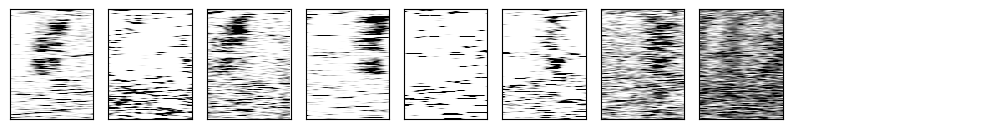

plotting vr rate maps using cluster_ids [75, 131, 137, 148, 170]
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320


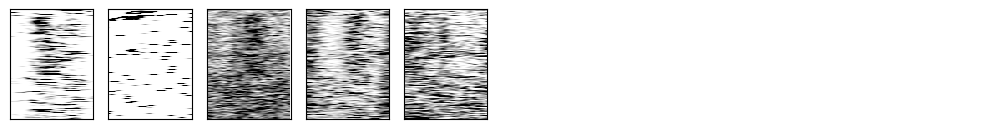

plotting vr rate maps using cluster_ids [47, 52, 54, 56, 65, 67, 71, 73, 76, 94, 97, 102, 105, 121, 127, 128, 130, 133, 134, 139, 142, 146, 147, 149, 153, 156, 157, 161, 163, 166, 167, 168, 169, 171, 174, 175, 177, 178, 180, 181, 182, 183, 188, 189, 191, 192, 193, 196, 202, 205, 206, 207, 211, 214, 215, 216, 221, 229, 234, 254, 262]
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trial

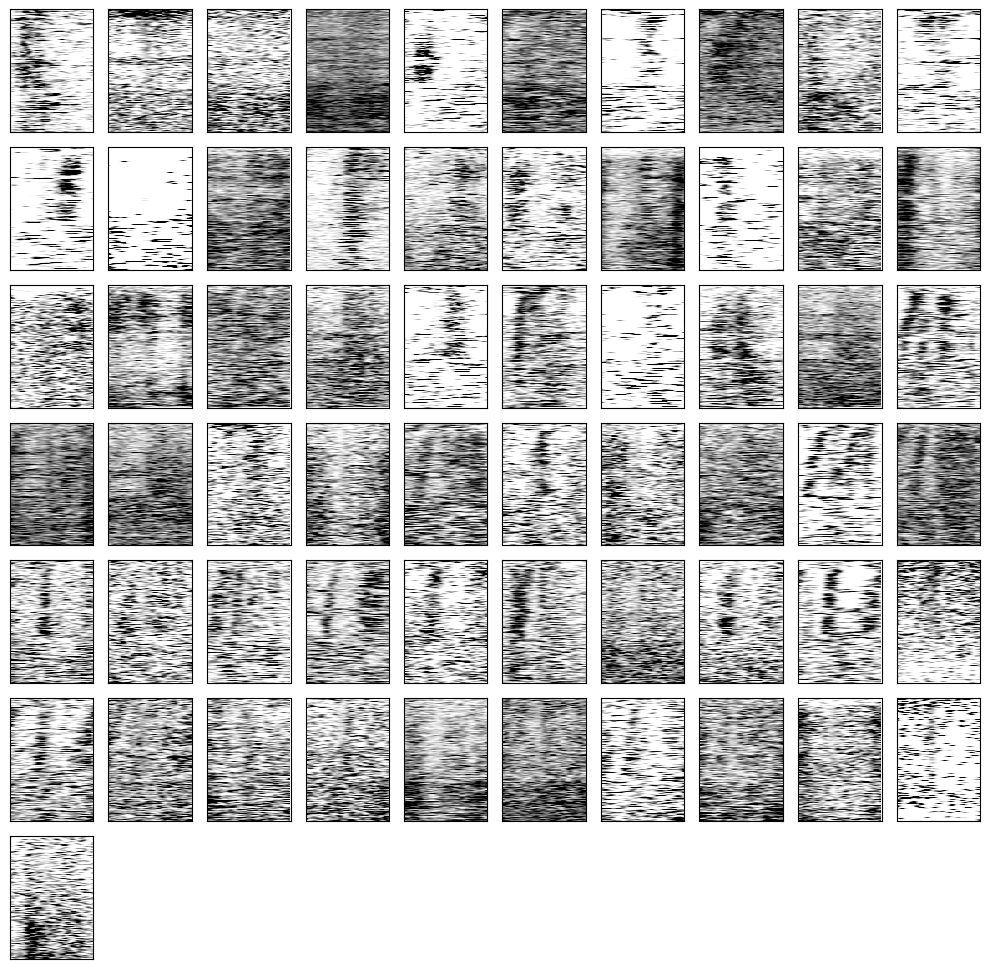

plotting vr rate maps using cluster_ids [35, 106, 129, 132, 141, 187, 194, 204, 209, 217, 223, 224, 226, 230, 264]
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320


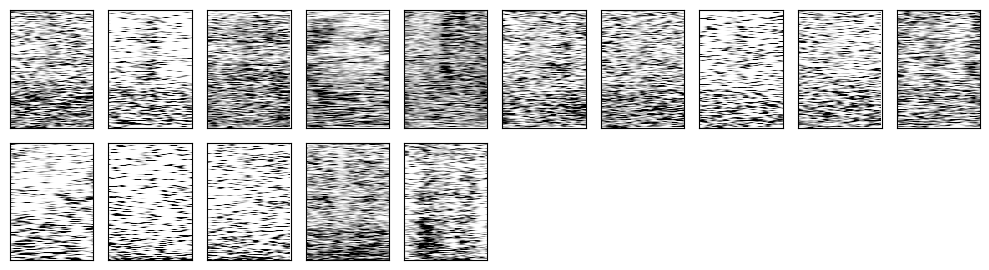

plotting vr rate maps using cluster_ids [62, 75, 90, 92, 109, 116, 131, 137, 145, 148, 158, 170, 203]
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320


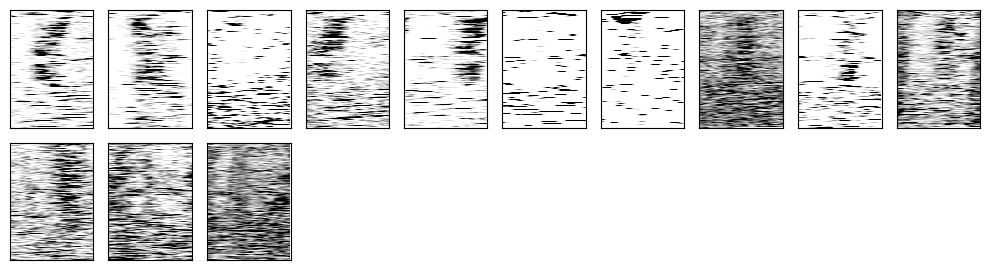

plotting vr rate maps using cluster_ids []


In [3]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
rc, rsc, vr_ns = cell_classification_vr(mouse, day)
_, _, _, _, _, _, _, all_by_anatomy = cell_classification_anatomy(mouse,day)
g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)

#plot_vr_rate_maps(mouse, day, rc.cluster_id.values, label=f'ramp_cells', figpath=fig_path)
#plot_vr_rate_maps(mouse, day, rsc.cluster_id.values, label=f'speed_ramp_cells', figpath=fig_path)

n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320
n trials: 320


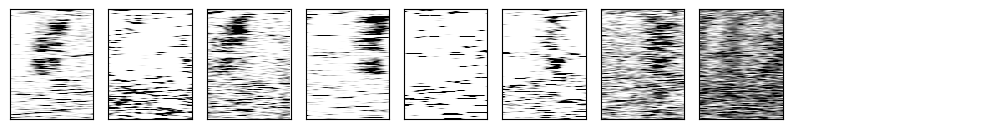

In [4]:
cluster_ids=cluster_ids_by_group[0]
tcs,tcs_time,_,_,_,_ = compute_vr_tcs(mouse, day)
ncols = 10
nrows = int(np.ceil(len(cluster_ids)/ncols))
fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=(10, 1.4*nrows), squeeze=False)
counter = 0
for j in range(nrows):
    for i in range(ncols):
        if counter<len(cluster_ids):
            index = cluster_ids[counter]
            plot_firing_rate_map(ax[j, i], 
                                zscore(tcs[index]),
                                bs=bs,
                                tl=tl,
                                p=95)
        else:
            ax[j, i].axis('off')
        counter+=1
        ax[j, i].set_xticks([])
        ax[j, i].set_yticks([])
        ax[j, i].xaxis.set_tick_params(labelbottom=False)
        ax[j, i].yaxis.set_tick_params(labelleft=False)
plt.tight_layout()
plt.show()

Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


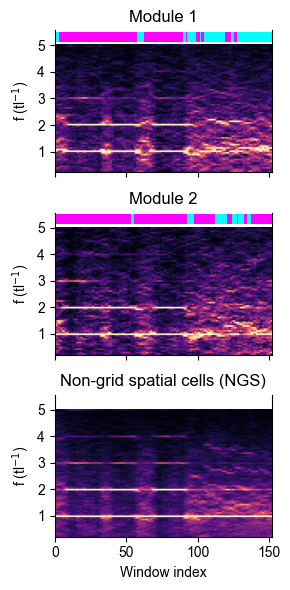

In [5]:


fig, ax = plt.subplots(nrows=len(g_m_cluster_ids)+1, ncols=1, figsize=(3, 6), squeeze=False, sharex=True)
peak_indices = [12, 28, 44, 60, 76]

for m in range(len(g_m_cluster_ids)):
    cluster_ids = g_m_cluster_ids[m]
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    fvalid = results[5]

    S = spectrograms.mean(0)
    ax[m,0].set_title(f'Module {m+1}')
    ax[m,0].imshow(S,origin='lower',aspect='auto',vmax=0.25,cmap='magma')
    max_peaks = np.argmax(S, axis=0)
    #ax[m,0].scatter(np.arange(S.shape[1]), max_peaks, color='#CAC841',s=3)
    ax[m,0].set_yticks(peak_indices, [1, 2, 3, 4, 5])
    ax[m,0].set_ylabel(r'f (tl$^{-1}$)')
    ax[m,0].spines['top'].set_visible(False)
    
    # Cluster labels: 1 if max at peak_indices_gm, else 0
    labels = np.isin(max_peaks, peak_indices).astype(int)
    ax[m,0].scatter(
        np.arange(S.shape[1]),
        np.full(S.shape[1], 81),  # y just above the top
        c=labels,
        cmap='cool',
        marker='s',
        s=50,
        vmin=0, 
        vmax=1,
        edgecolor='none',
        clip_on=True
    )

# Non-grid spatial
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
S = spectrograms.mean(0)

ax[-1,0].set_title(f'Non-grid spatial cells (NGS)')
ax[-1,0].imshow(S,origin='lower',aspect='auto',vmax=0.25,cmap='magma')
max_peaks = np.argmax(S, axis=0)
#ax[-1,0].scatter(np.arange(S.shape[1]), max_peaks, color='#6897CD',s=3)
ax[-1,0].set_yticks(peak_indices, [1, 2, 3, 4, 5])
ax[-1,0].set_ylabel(r'f (tl$^{-1}$)')
ax[-1,0].set_xlabel('Window index')
ax[-1,0].spines['top'].set_visible(False)
labels = np.isin(max_peaks, peak_indices).astype(int)
ax[-1,0].scatter(
    np.arange(S.shape[1]),
    np.full(S.shape[1], 81),  # y just above the top
    c=labels,
    cmap='cool',
    marker='s',
    vmin=0, 
    vmax=1,
    s=50,
    alpha=0,
    edgecolor='none',
    clip_on=True
)

plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/M{mouse}D{day}_joint_spectrograms.pdf',  bbox_inches='tight')
plt.show()

Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


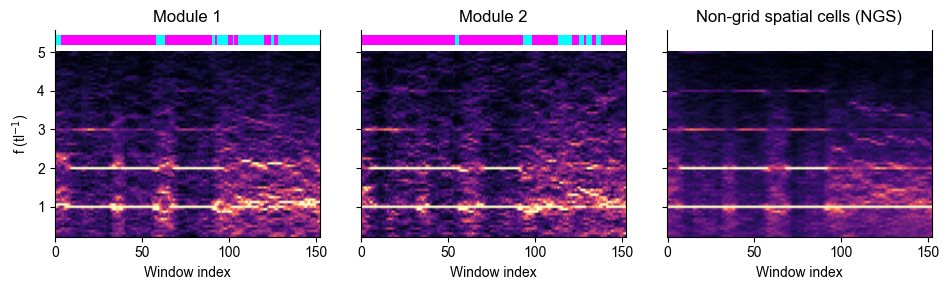

In [6]:
fig, ax = plt.subplots(nrows=1, ncols=len(g_m_cluster_ids)+1, figsize=(3.2*(len(g_m_cluster_ids)+1), 3), squeeze=False, sharey=True)
peak_indices = [12, 28, 44, 60, 76]

for m in range(len(g_m_cluster_ids)):
    cluster_ids = g_m_cluster_ids[m]
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3]
    fvalid = results[5]

    S = spectrograms.mean(0)
    ax[0, m].set_title(f'Module {m+1}')
    ax[0, m].imshow(S, origin='lower', aspect='auto', vmax=0.25, cmap='magma')
    max_peaks = np.argmax(S, axis=0)
    ax[0, m].set_yticks(peak_indices)
    ax[0, m].set_yticklabels([1, 2, 3, 4, 5])
    ax[0, m].spines['top'].set_visible(False)
    ax[0, m].set_xlabel('Window index')

    # Cluster labels: 1 if max at peak_indices_gm, else 0
    labels = np.isin(max_peaks, peak_indices).astype(int)
    ax[0, m].scatter(
        np.arange(S.shape[1]),
        np.full(S.shape[1], 81),  # y just above the top
        c=labels,
        cmap='cool',
        marker='s',
        s=50,
        vmin=0,
        vmax=1,
        edgecolor='none',
        clip_on=True
    )

# Non-grid spatial
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3]
S = spectrograms.mean(0)

ax[0, -1].set_title('Non-grid spatial cells (NGS)')
ax[0, -1].imshow(S, origin='lower', aspect='auto', vmax=0.25, cmap='magma')
max_peaks = np.argmax(S, axis=0)
ax[0, -1].set_yticks(peak_indices)
ax[0, -1].set_yticklabels([1, 2, 3, 4, 5])
ax[0, 0].set_ylabel(r'f (tl$^{-1}$)')
ax[0, -1].set_xlabel('Window index')
ax[0, -1].spines['top'].set_visible(False)
labels = np.isin(max_peaks, peak_indices).astype(int)
ax[0, -1].scatter(
    np.arange(S.shape[1]),
    np.full(S.shape[1], 81),  # y just above the top
    c=labels,
    cmap='cool',
    marker='s',
    vmin=0,
    vmax=1,
    s=50,
    alpha=0,
    edgecolor='none',
    clip_on=True
)

plt.tight_layout(w_pad=2)
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/M{mouse}D{day}_joint_spectrograms.pdf', bbox_inches='tight')
plt.show()

In [7]:
# Calculate mean probe_x and probe_y for cluster_ids in g_m_cluster_ids[0]
cluster_ids = g_m_cluster_ids[0]
subset = all[all['cluster_id'].isin(cluster_ids)]
mean_x = subset['probe_x'].mean()
mean_y = subset['probe_y'].mean()
print(f"Mean probe_x: {mean_x:.2f}, Mean probe_y: {mean_y:.2f}")

Mean probe_x: 270.00, Mean probe_y: 1081.88


Identified 1 candidate modules
Processing cell 1/89: ID 35


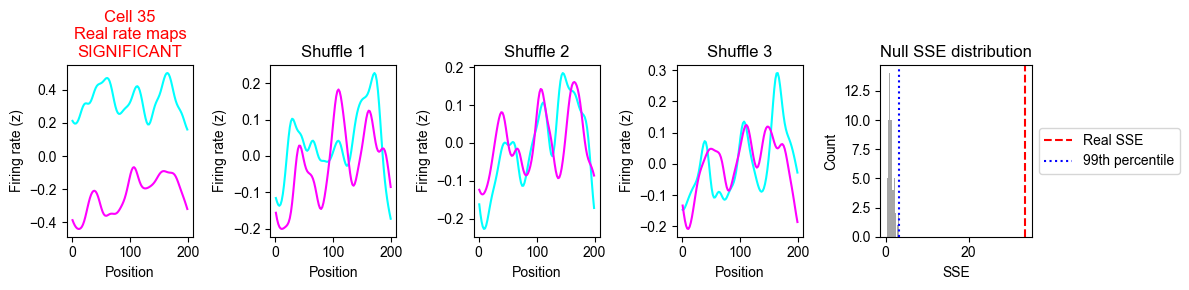

Processing cell 2/89: ID 47


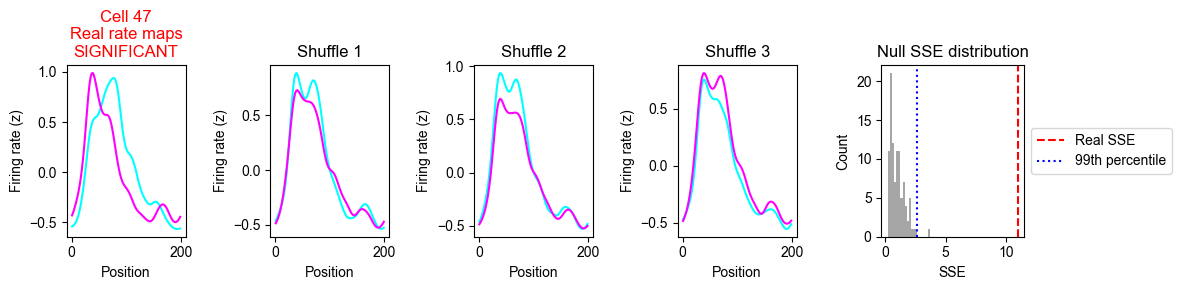

Processing cell 3/89: ID 52


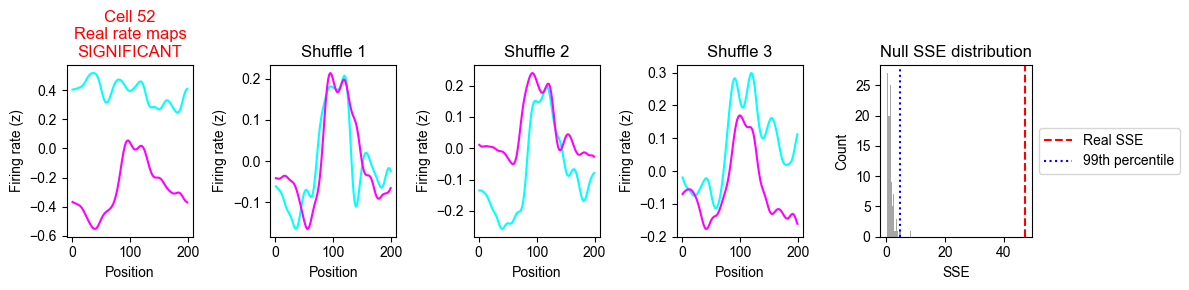

Processing cell 4/89: ID 54


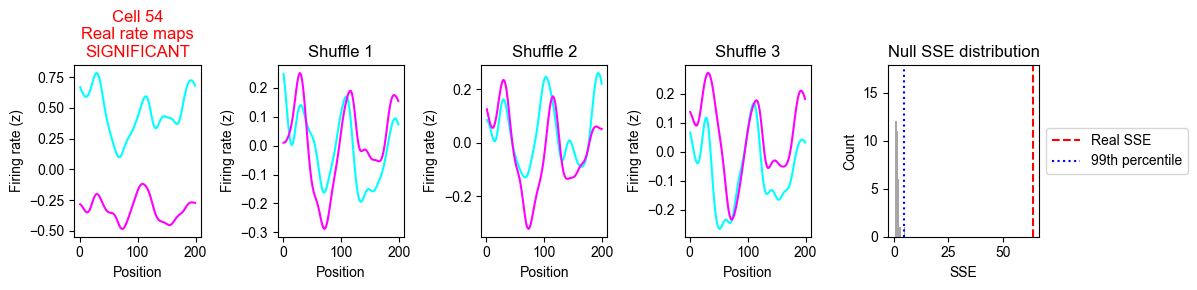

Processing cell 5/89: ID 56


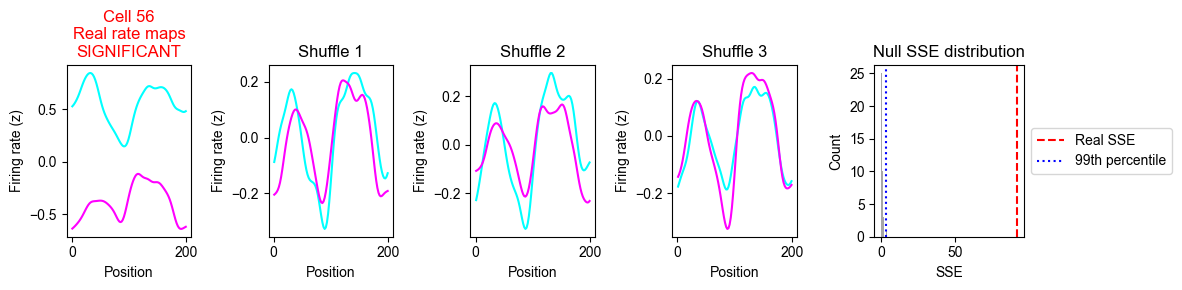

Processing cell 6/89: ID 62


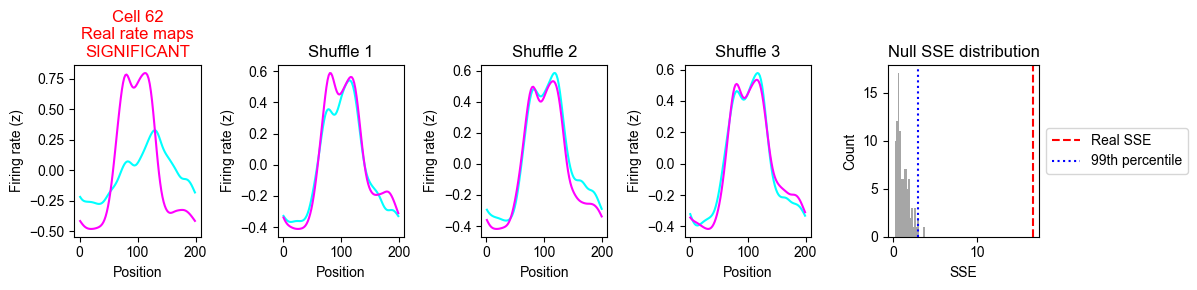

Processing cell 7/89: ID 65


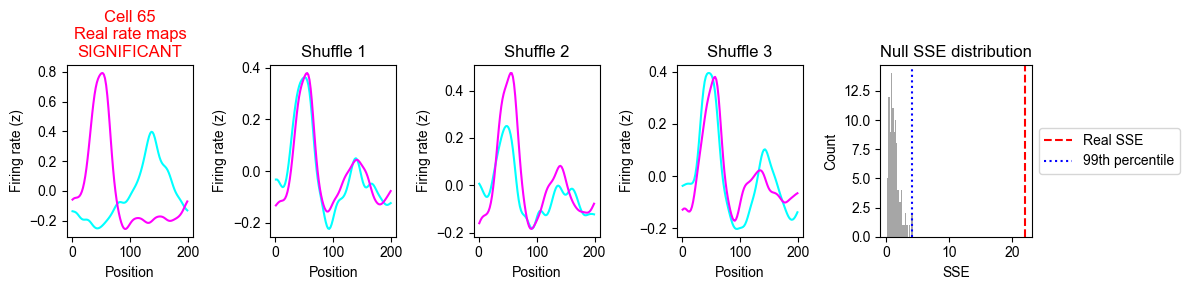

Processing cell 8/89: ID 67


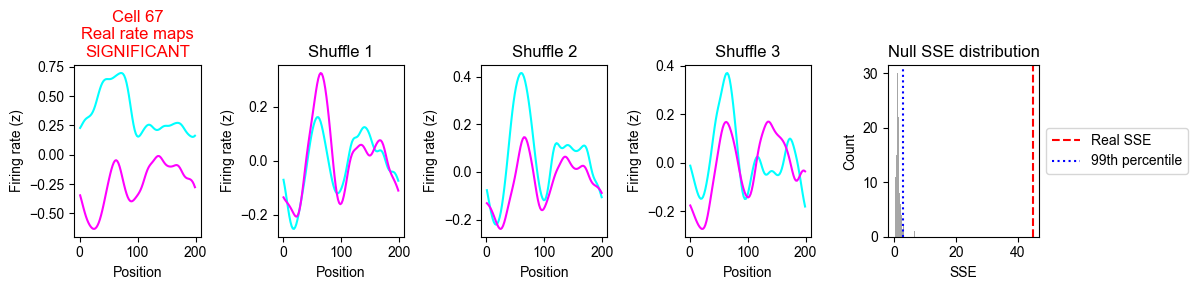

Processing cell 9/89: ID 71


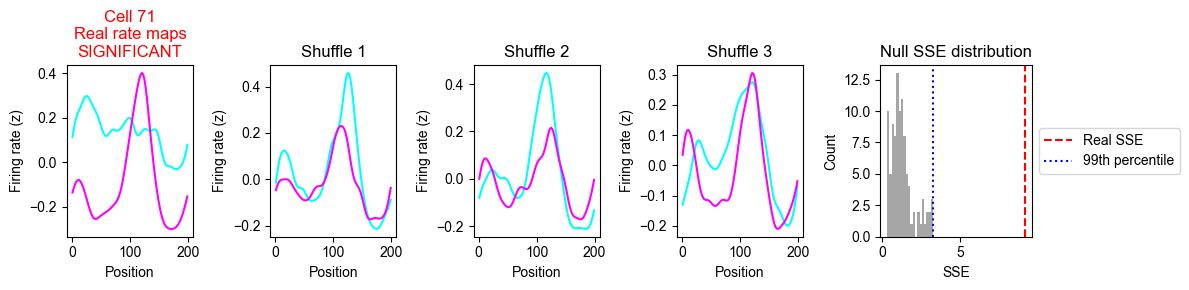

Processing cell 10/89: ID 73


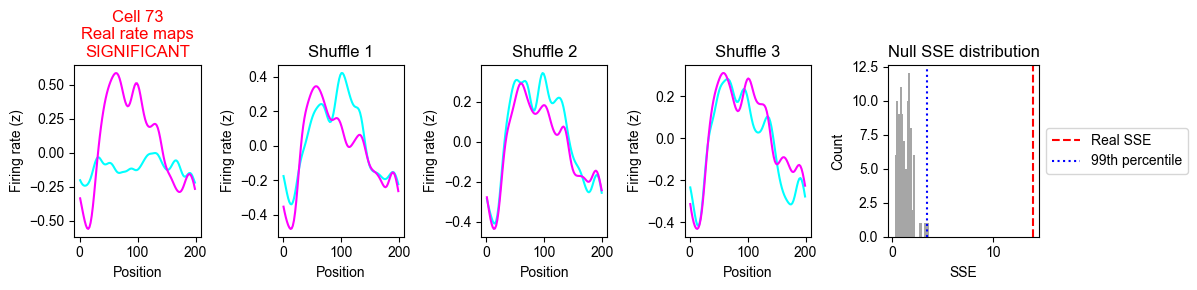

Processing cell 11/89: ID 75


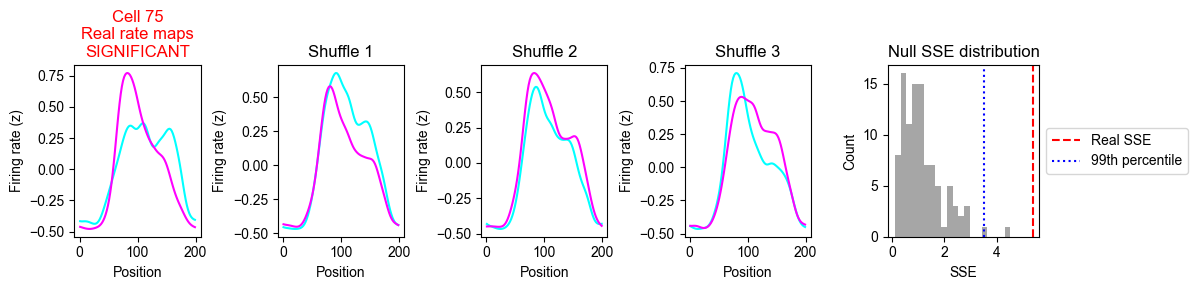

Processing cell 12/89: ID 76


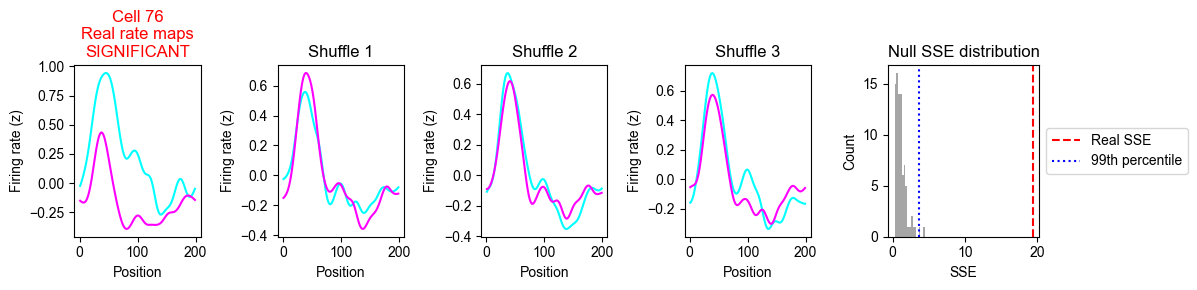

Processing cell 13/89: ID 90


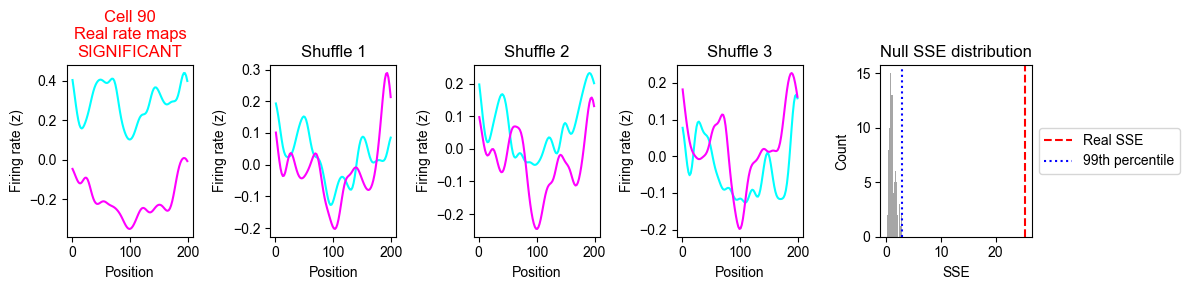

Processing cell 14/89: ID 92


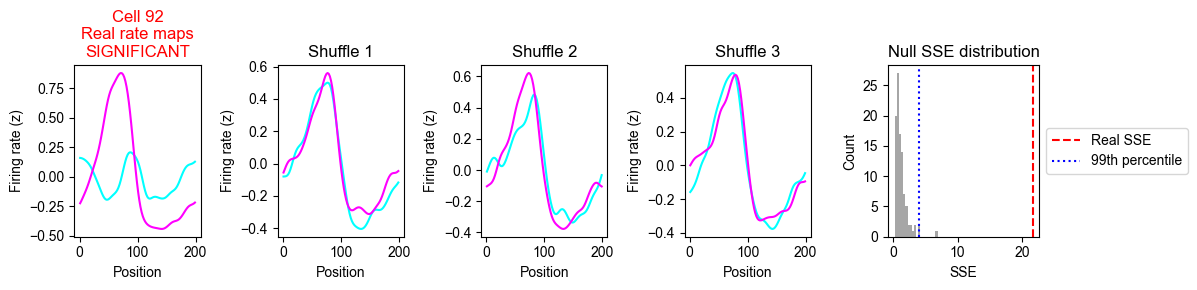

Processing cell 15/89: ID 94


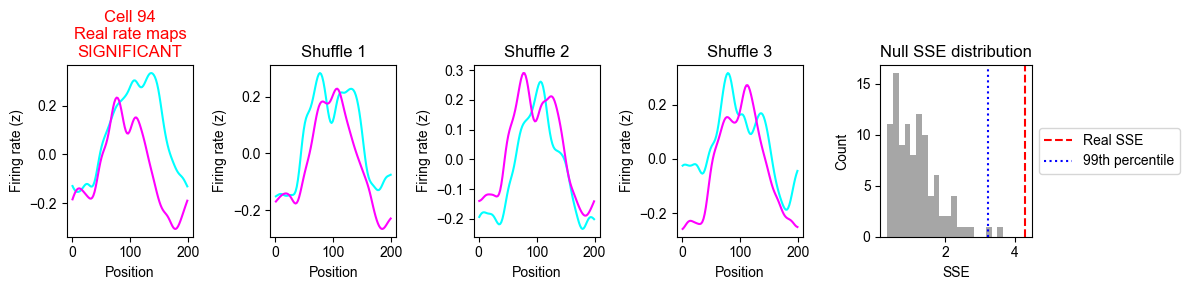

Processing cell 16/89: ID 97


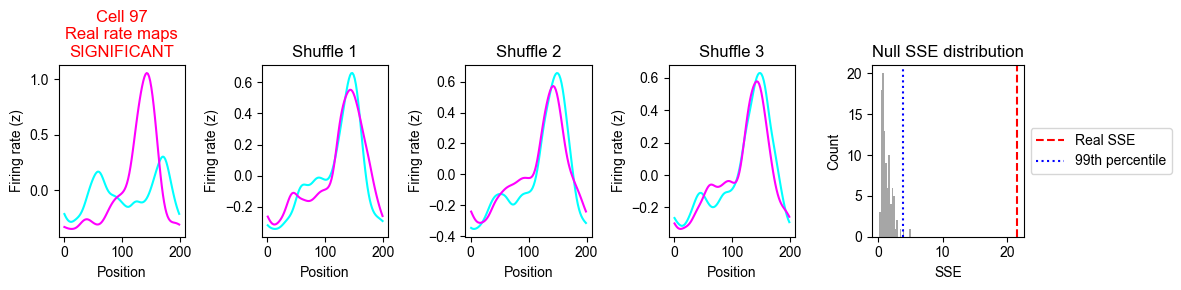

Processing cell 17/89: ID 102


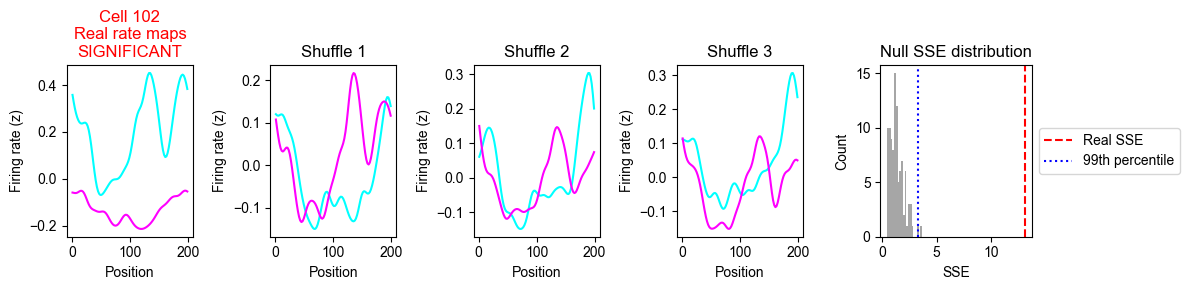

Processing cell 18/89: ID 105


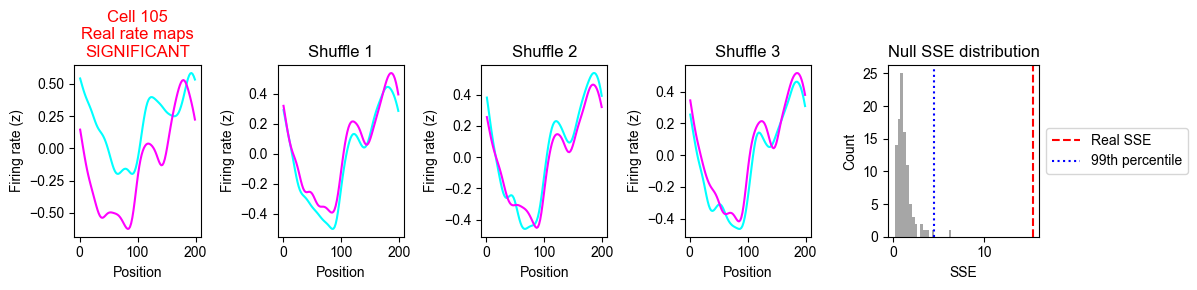

Processing cell 19/89: ID 106


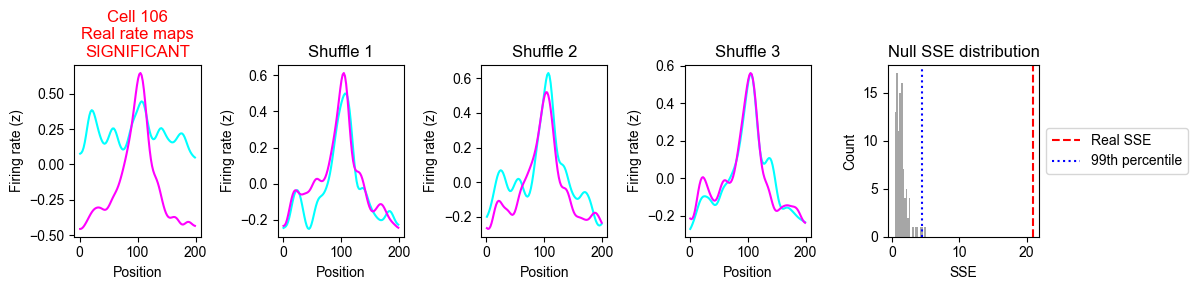

Processing cell 20/89: ID 109


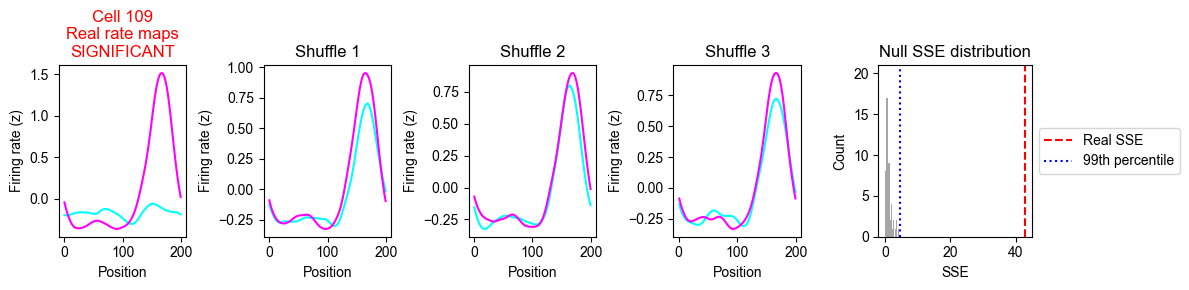

Processing cell 21/89: ID 116


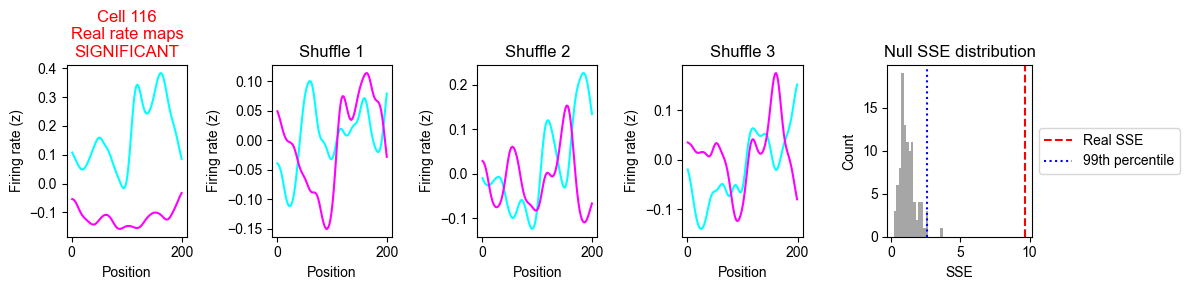

Processing cell 22/89: ID 121


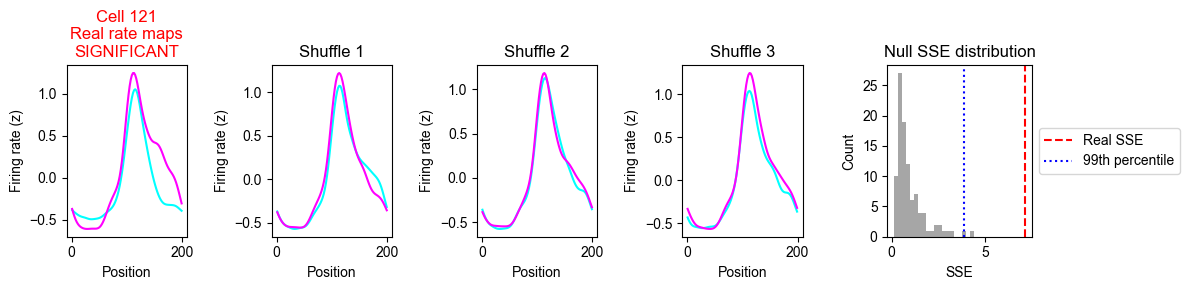

Processing cell 23/89: ID 127


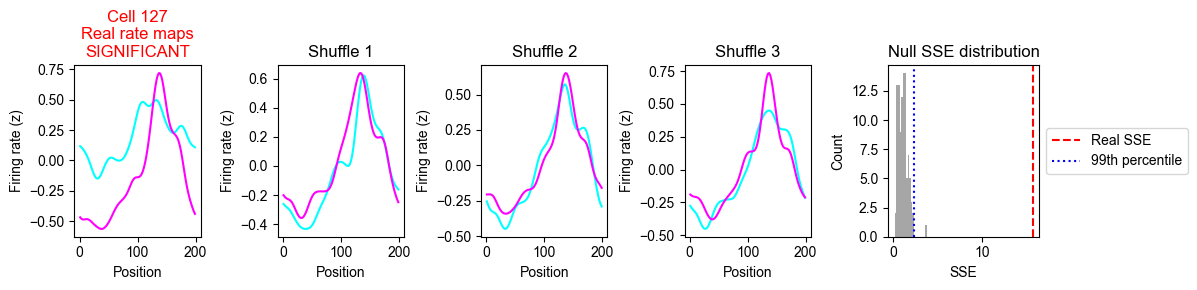

Processing cell 24/89: ID 128


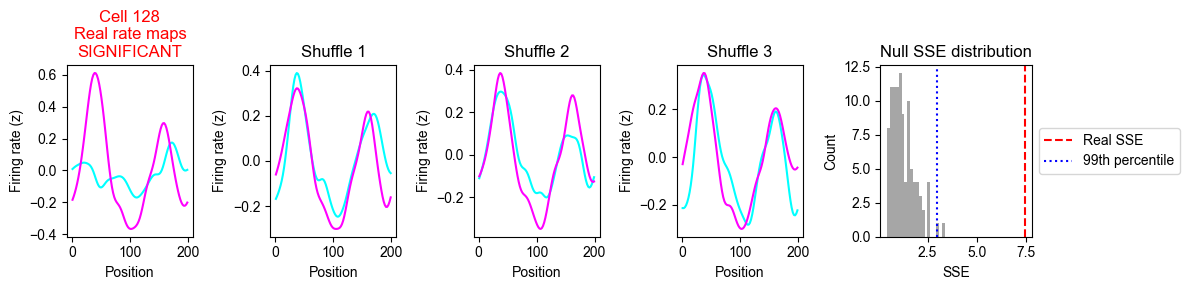

Processing cell 25/89: ID 129


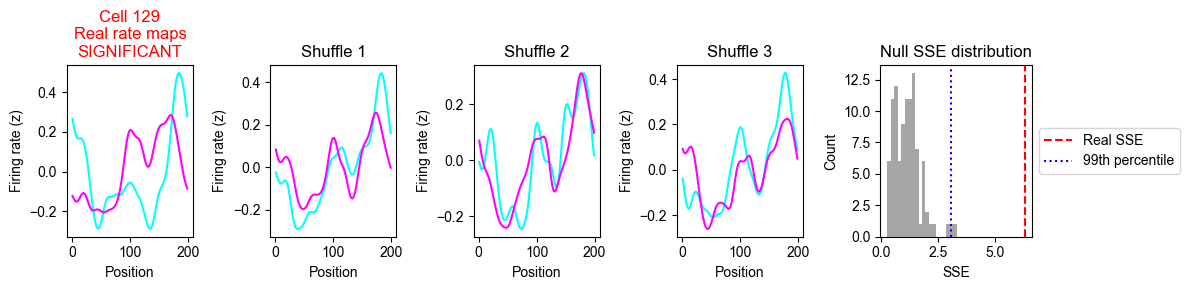

Processing cell 26/89: ID 130


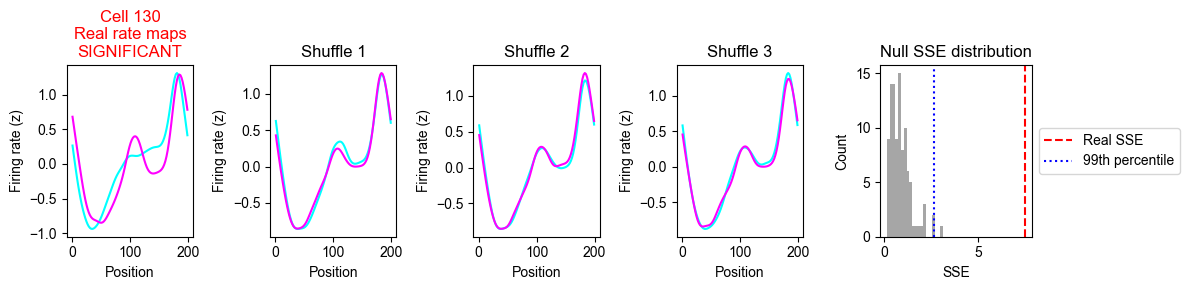

Processing cell 27/89: ID 131


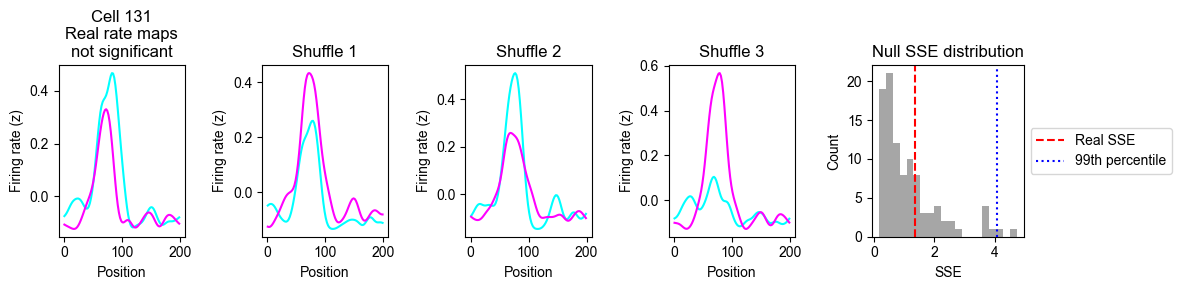

Processing cell 28/89: ID 132


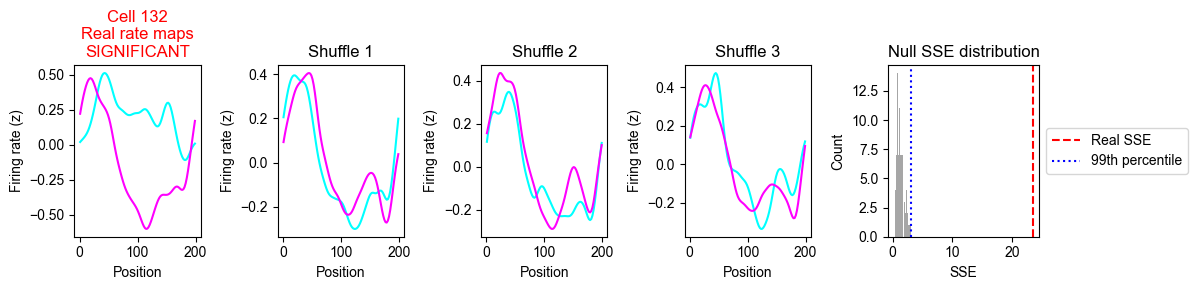

Processing cell 29/89: ID 133


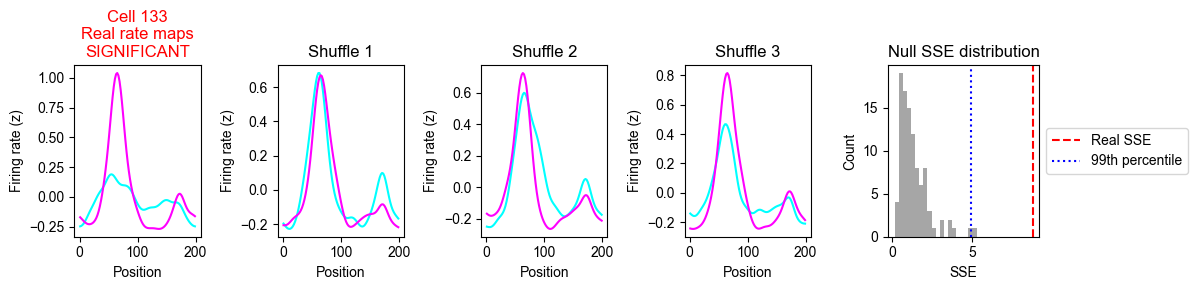

Processing cell 30/89: ID 134


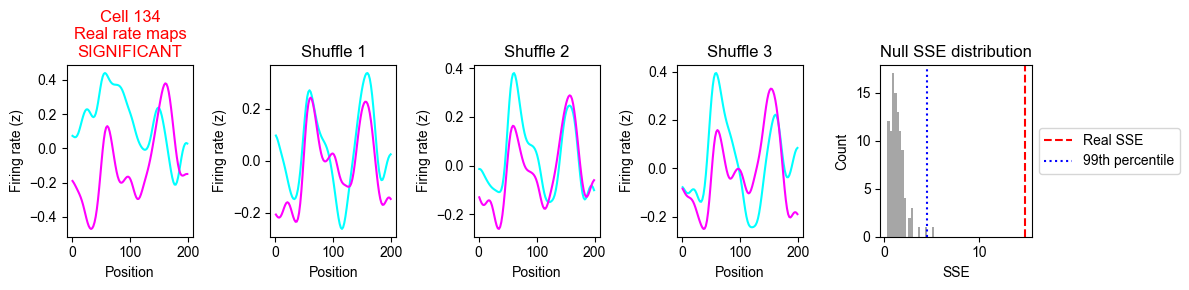

Processing cell 31/89: ID 137


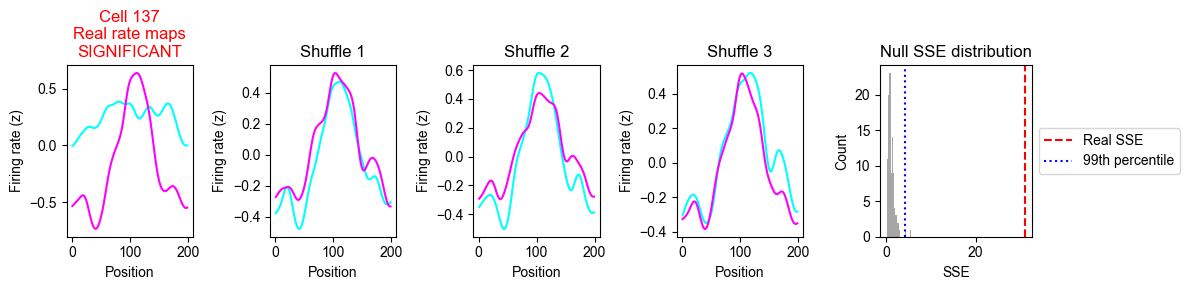

Processing cell 32/89: ID 139


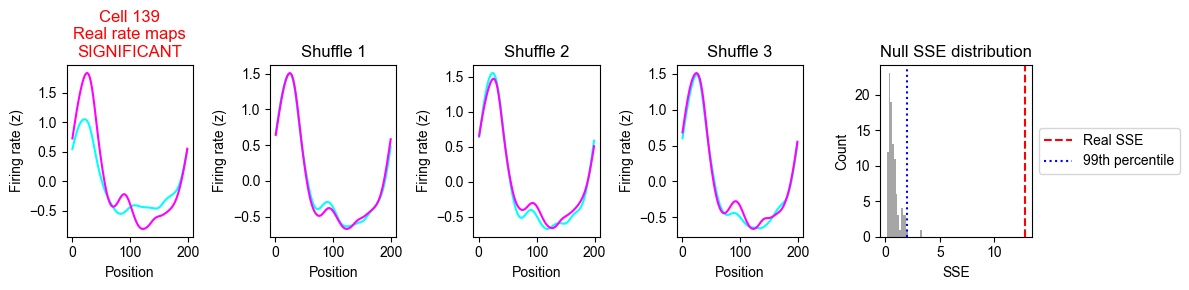

Processing cell 33/89: ID 141


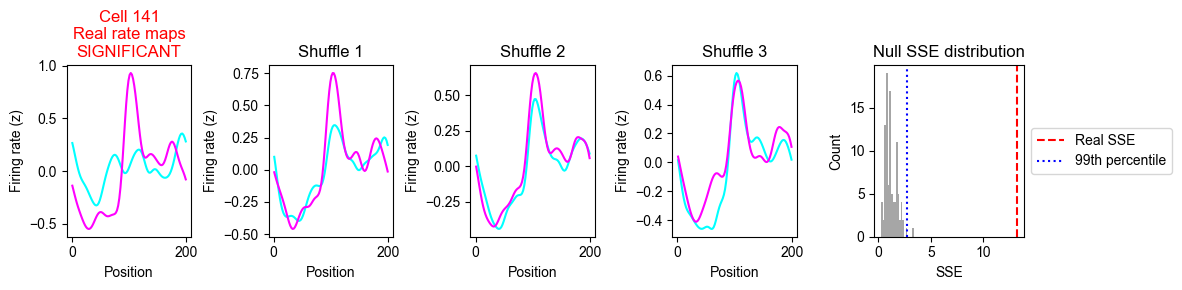

Processing cell 34/89: ID 142


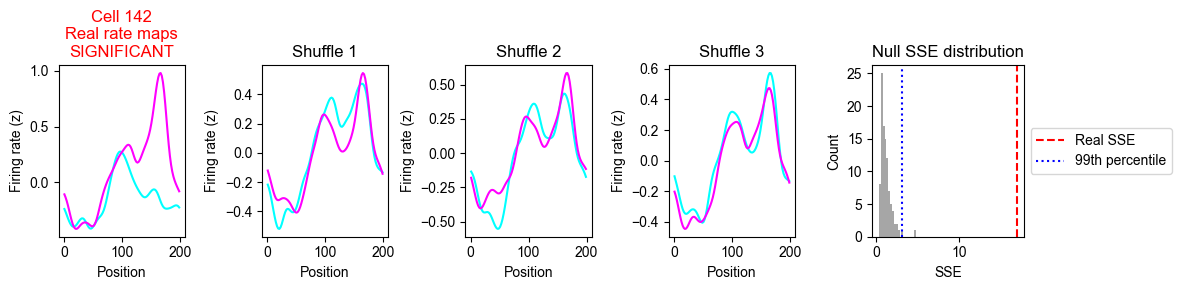

Processing cell 35/89: ID 145


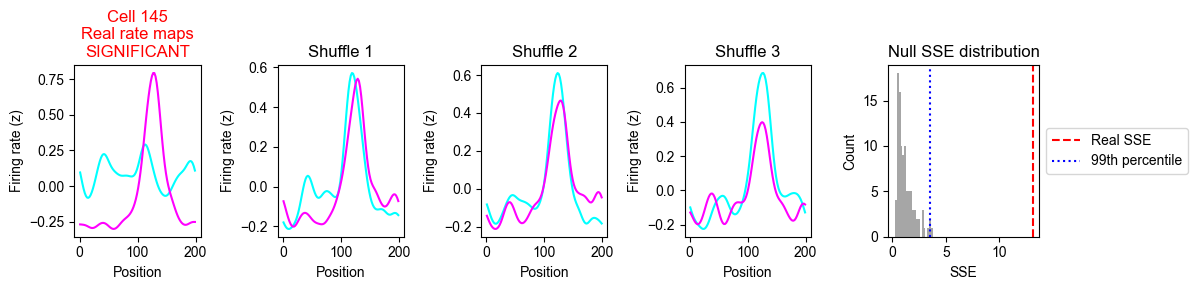

Processing cell 36/89: ID 146


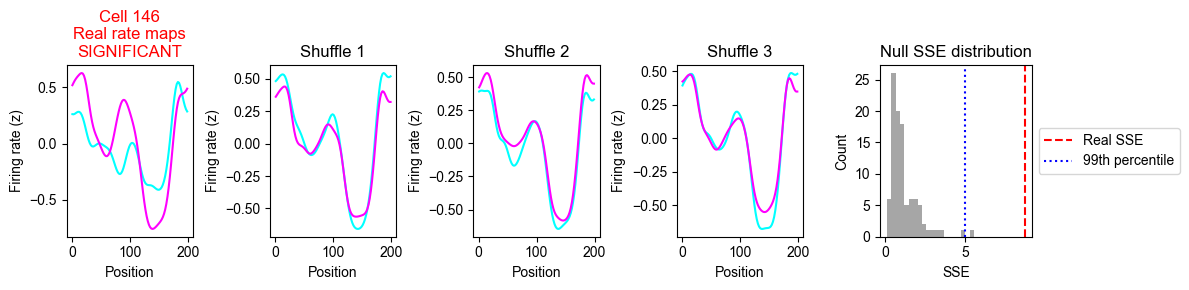

Processing cell 37/89: ID 147


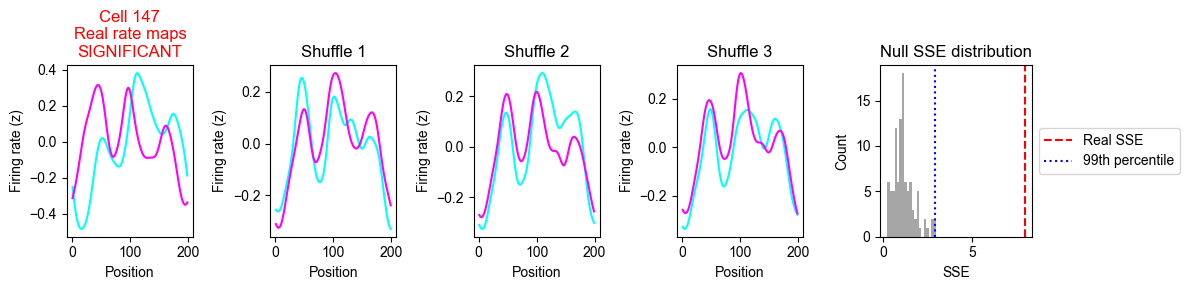

Processing cell 38/89: ID 148


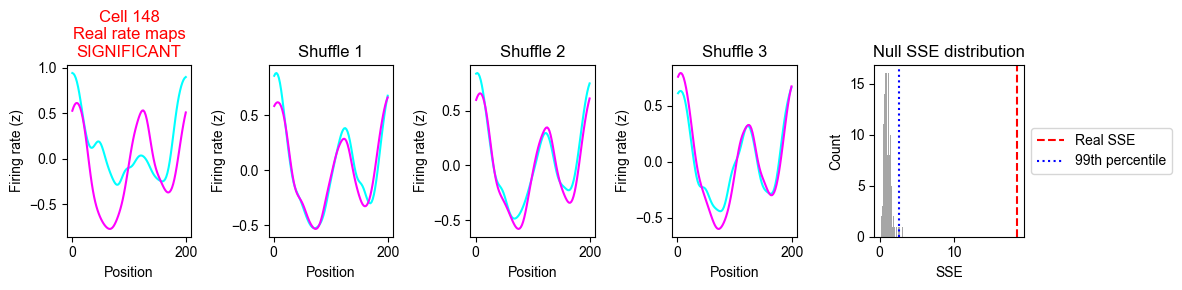

Processing cell 39/89: ID 149


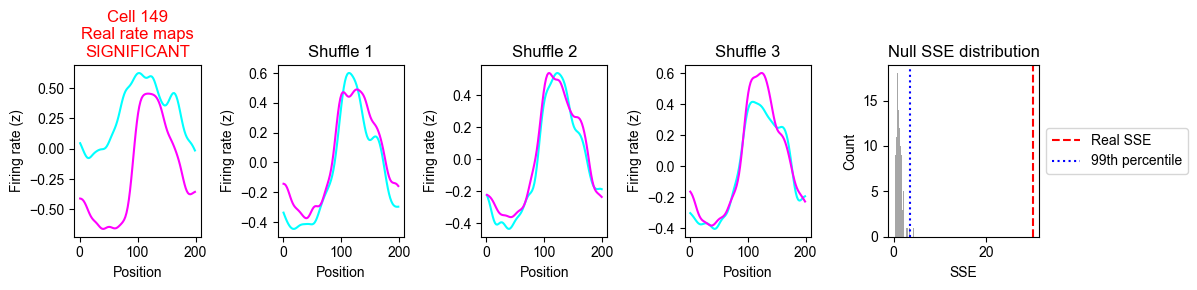

Processing cell 40/89: ID 153


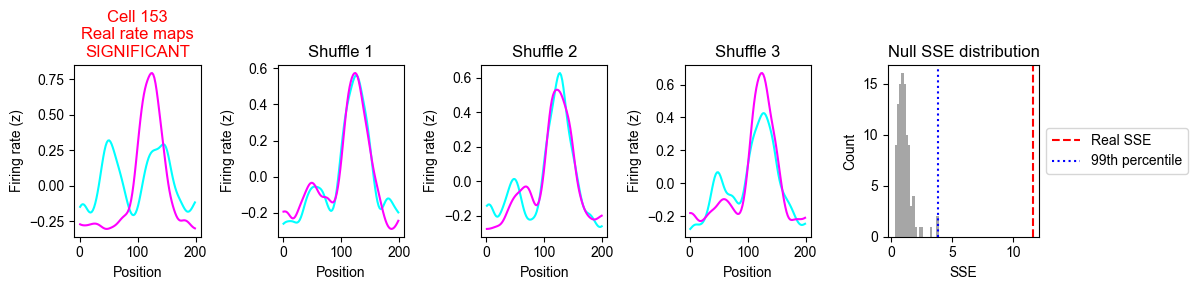

Processing cell 41/89: ID 156


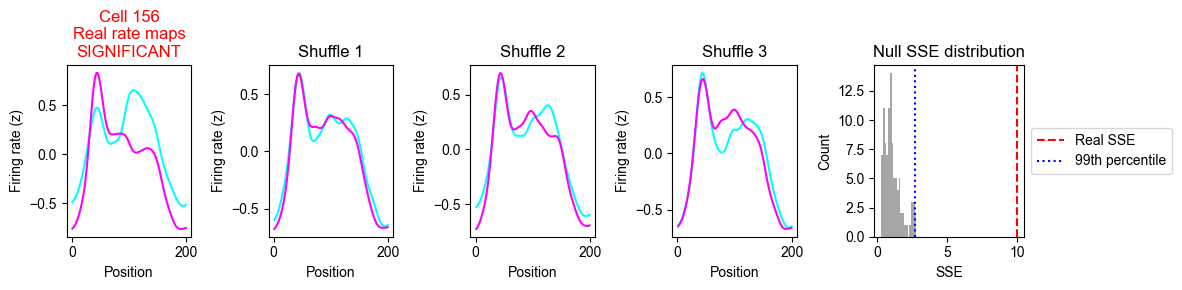

Processing cell 42/89: ID 157


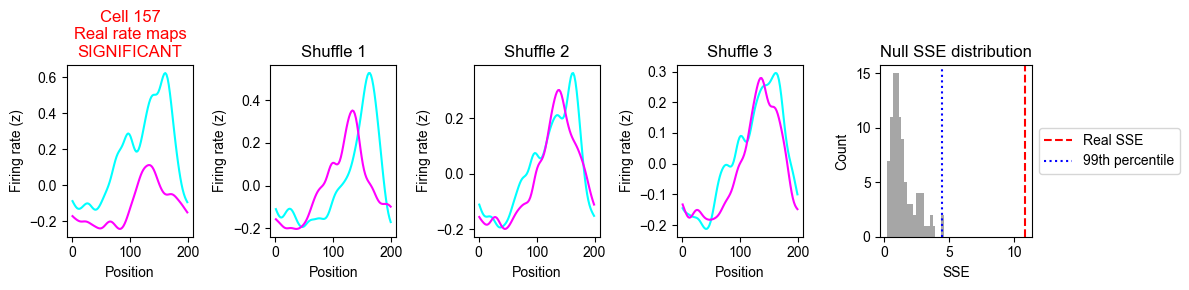

Processing cell 43/89: ID 158


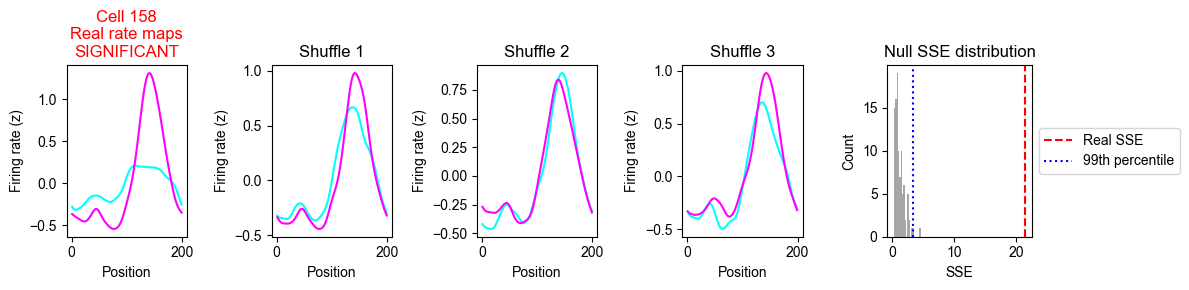

Processing cell 44/89: ID 161


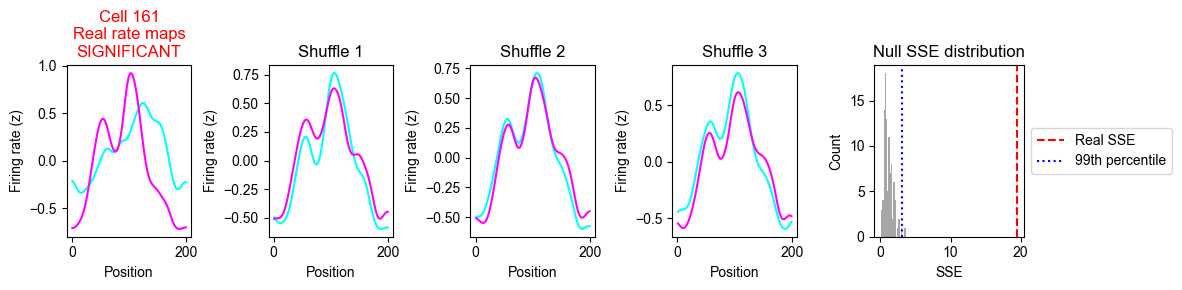

Processing cell 45/89: ID 163


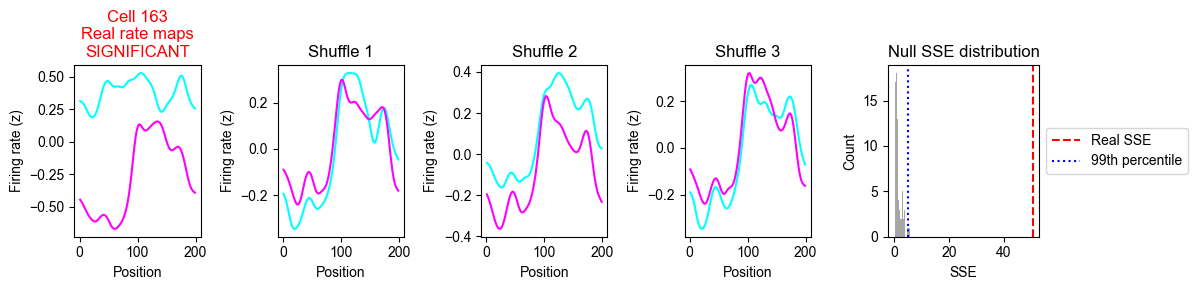

Processing cell 46/89: ID 166


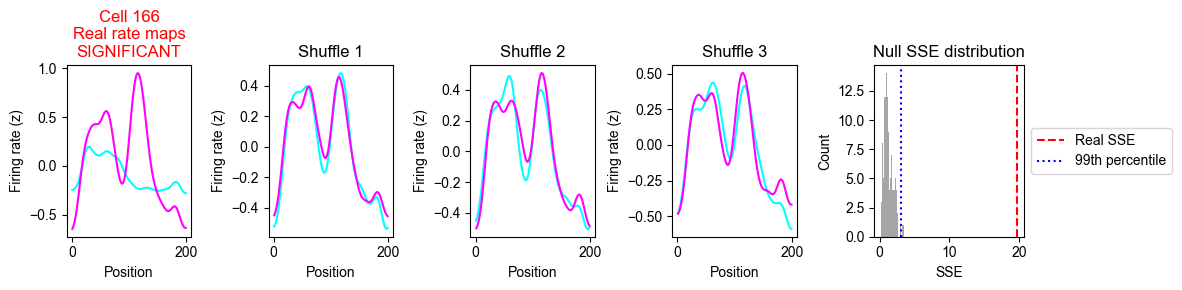

Processing cell 47/89: ID 167


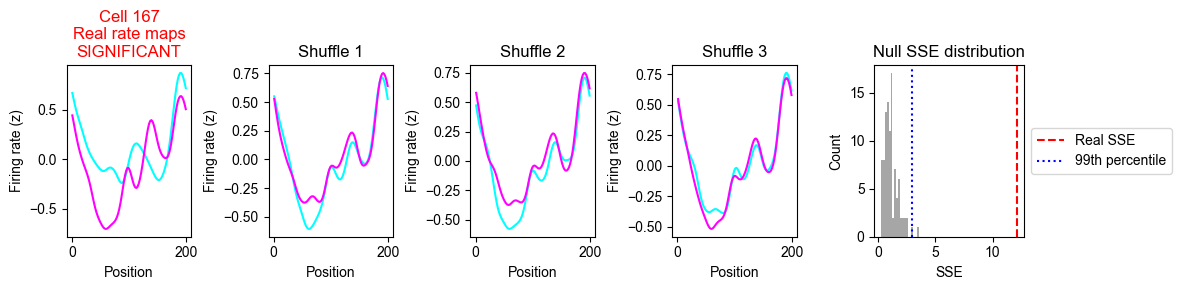

Processing cell 48/89: ID 168


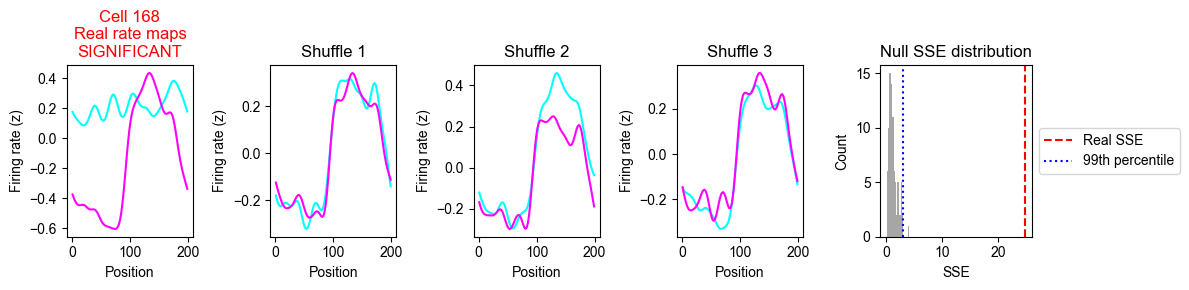

Processing cell 49/89: ID 169


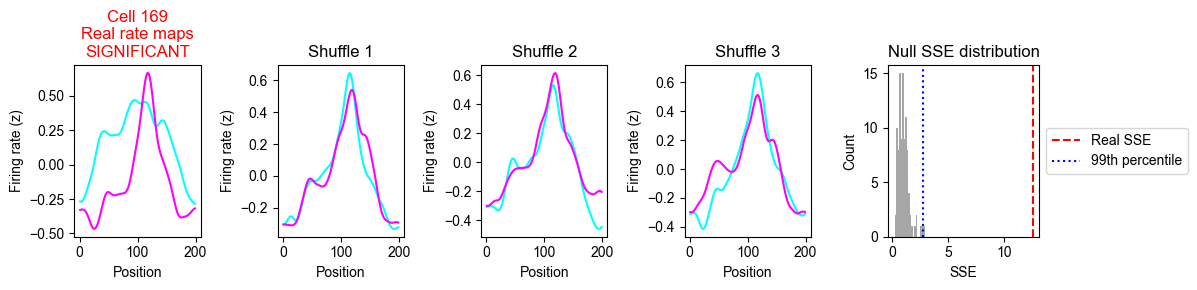

Processing cell 50/89: ID 170


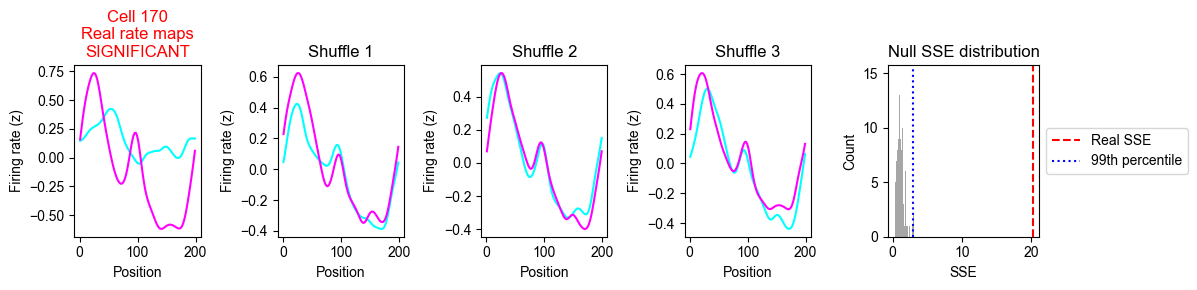

Processing cell 51/89: ID 171


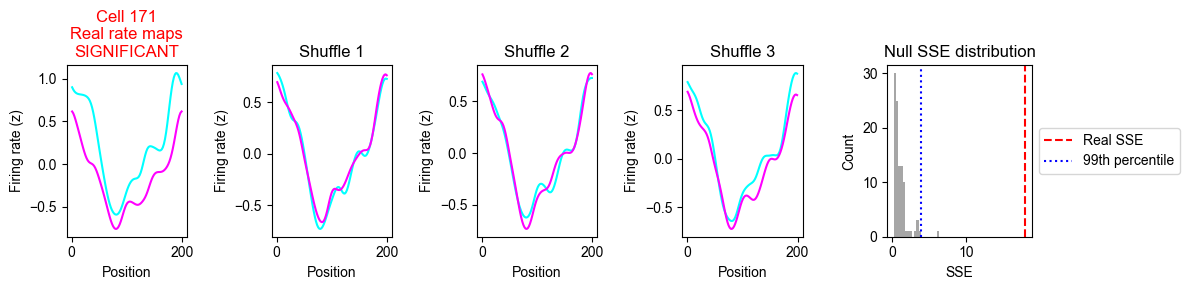

Processing cell 52/89: ID 174


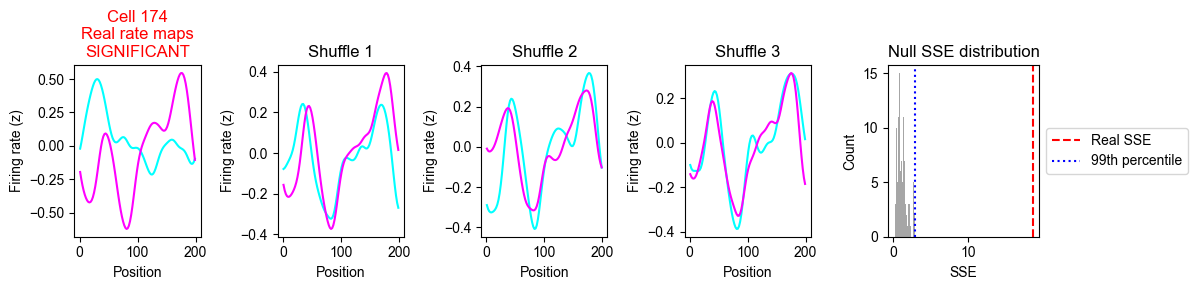

Processing cell 53/89: ID 175


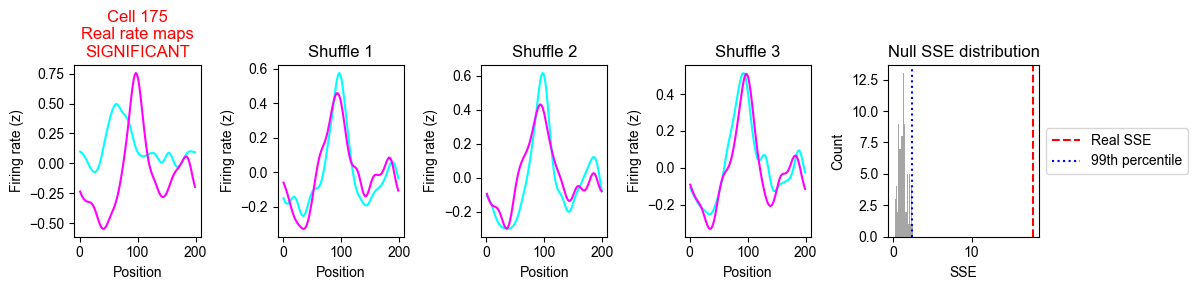

Processing cell 54/89: ID 177


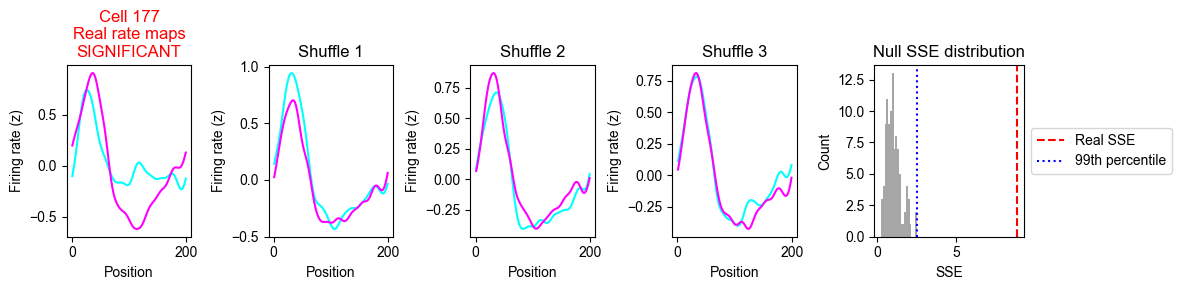

Processing cell 55/89: ID 178


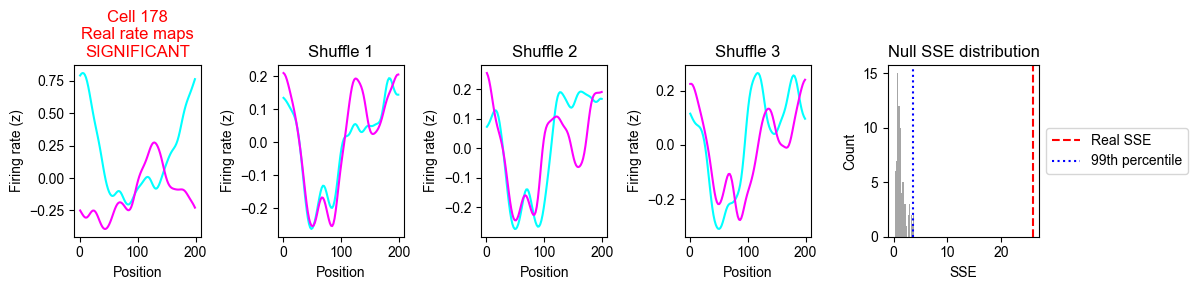

Processing cell 56/89: ID 180


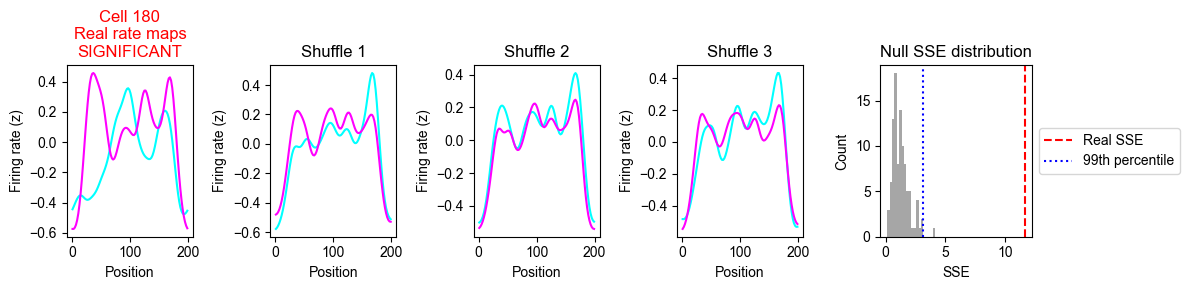

Processing cell 57/89: ID 181


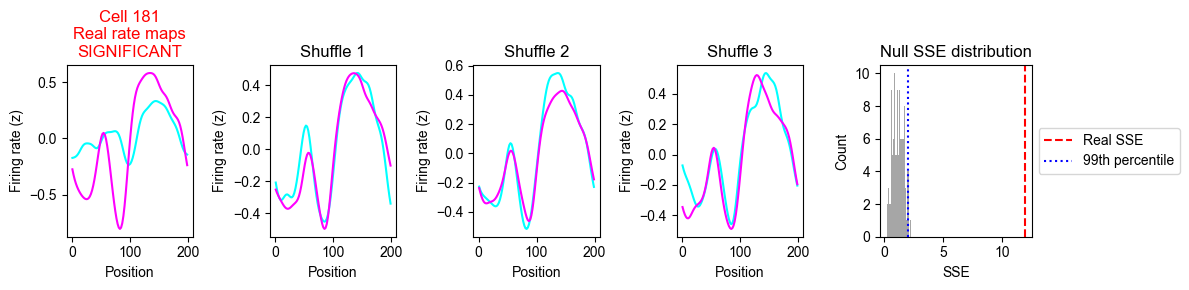

Processing cell 58/89: ID 182


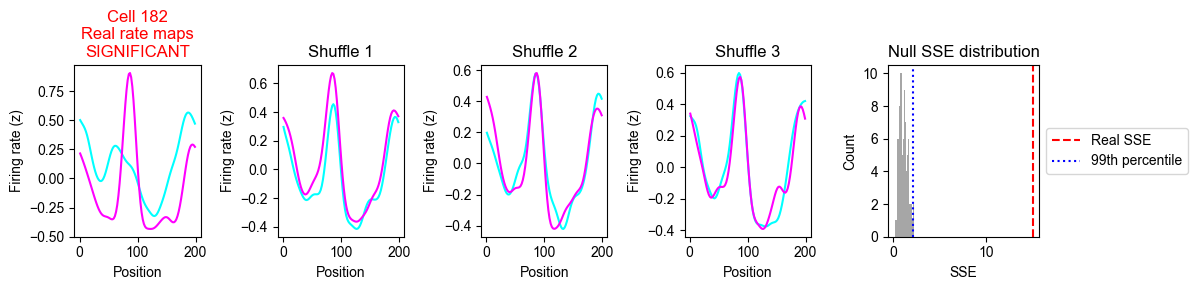

Processing cell 59/89: ID 183


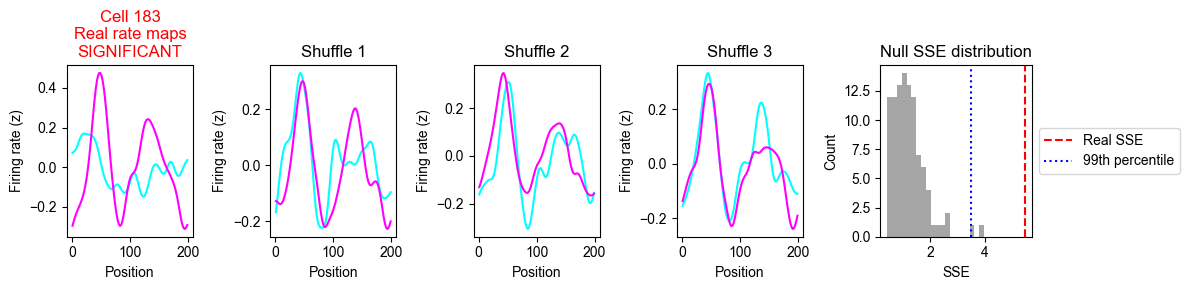

Processing cell 60/89: ID 187


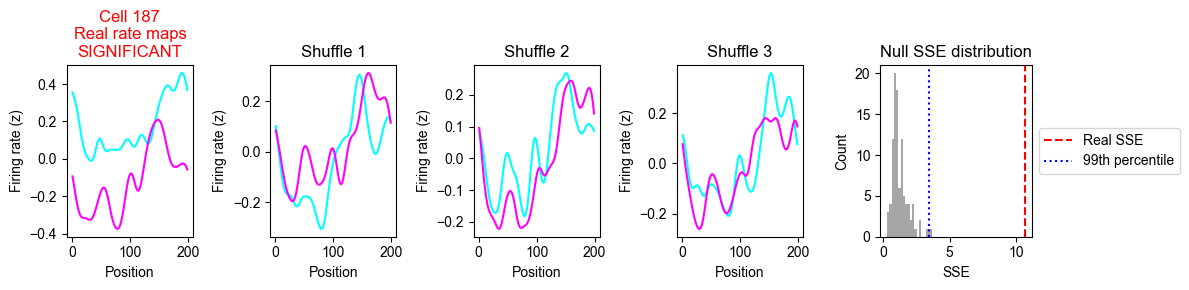

Processing cell 61/89: ID 188


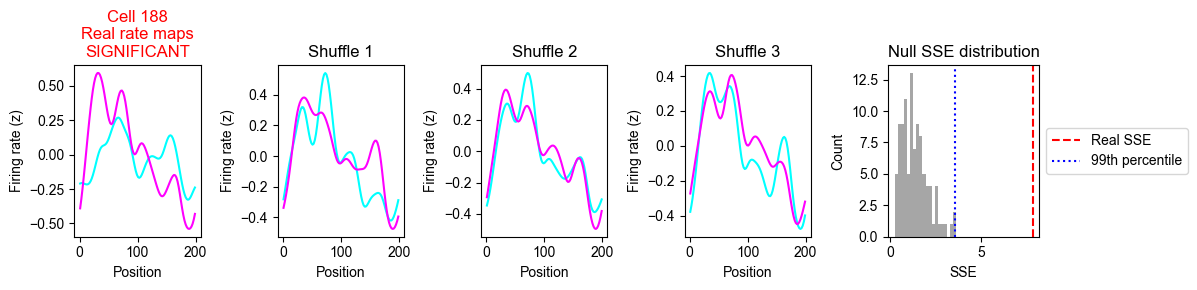

Processing cell 62/89: ID 189


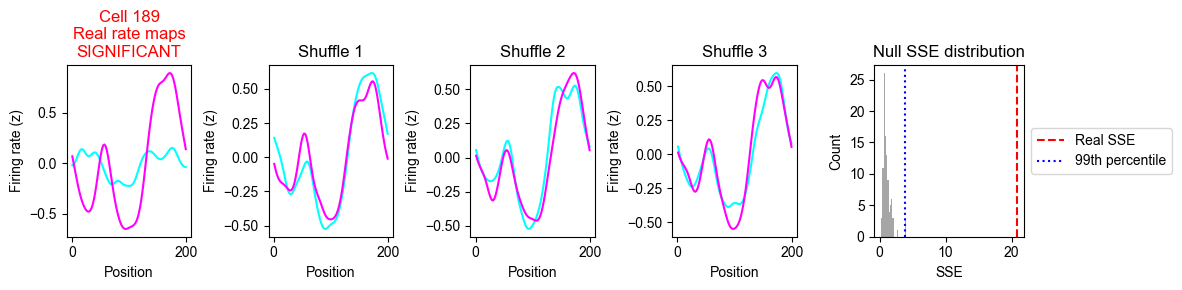

Processing cell 63/89: ID 191


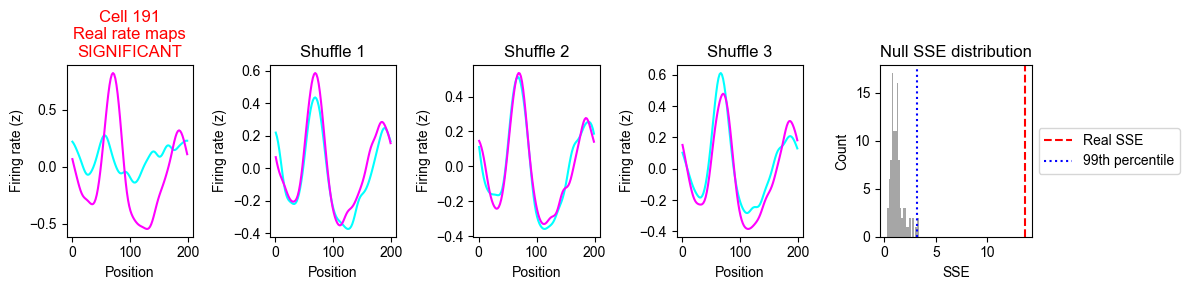

Processing cell 64/89: ID 192


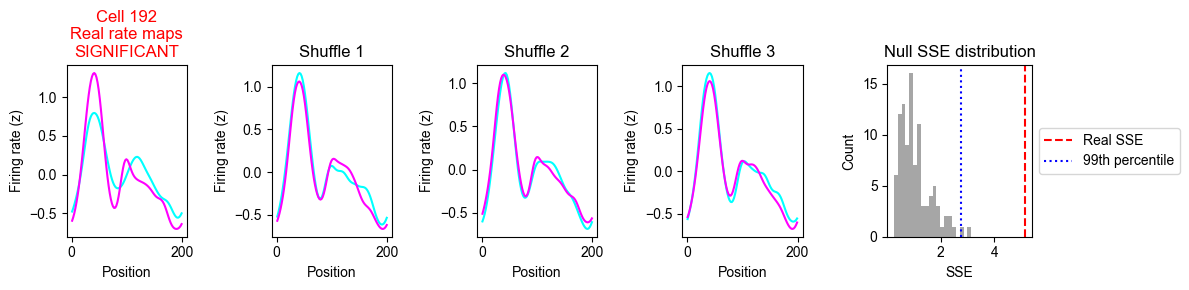

Processing cell 65/89: ID 193


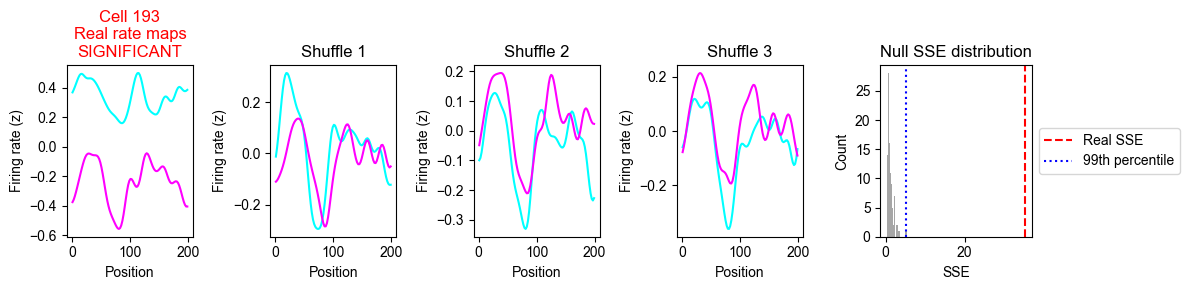

Processing cell 66/89: ID 194


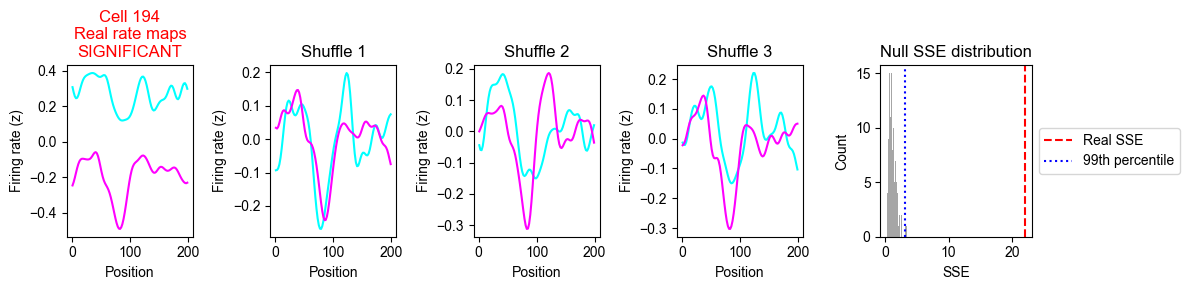

Processing cell 67/89: ID 196


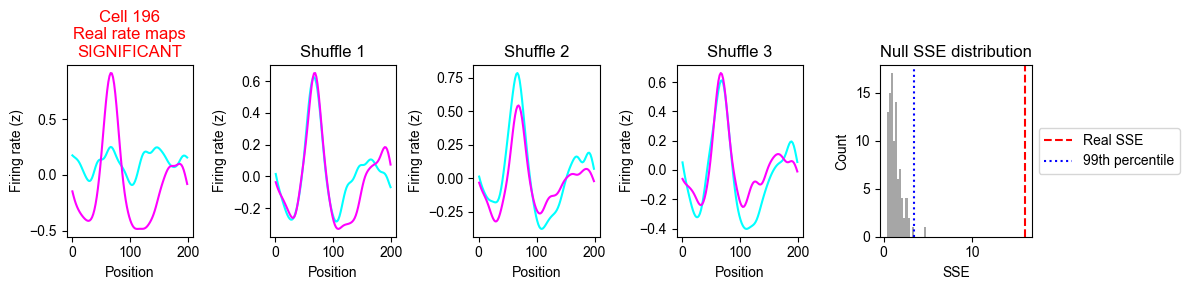

Processing cell 68/89: ID 202


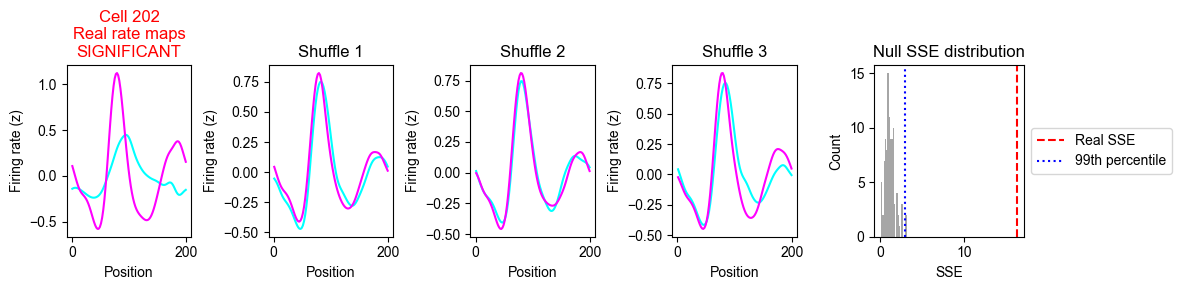

Processing cell 69/89: ID 203


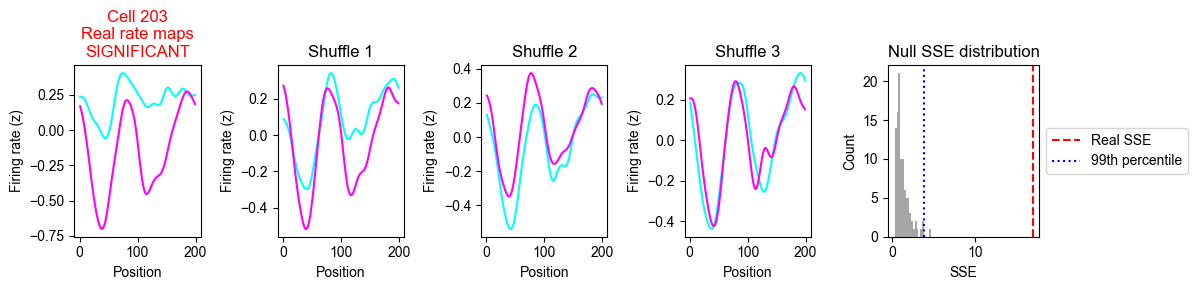

Processing cell 70/89: ID 204


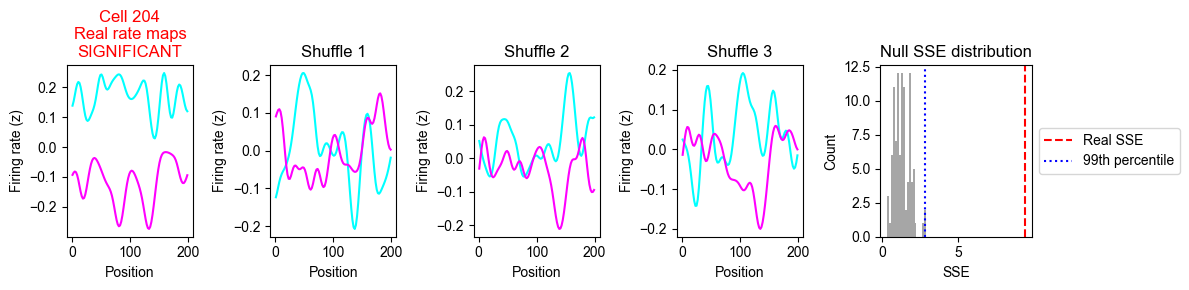

Processing cell 71/89: ID 205


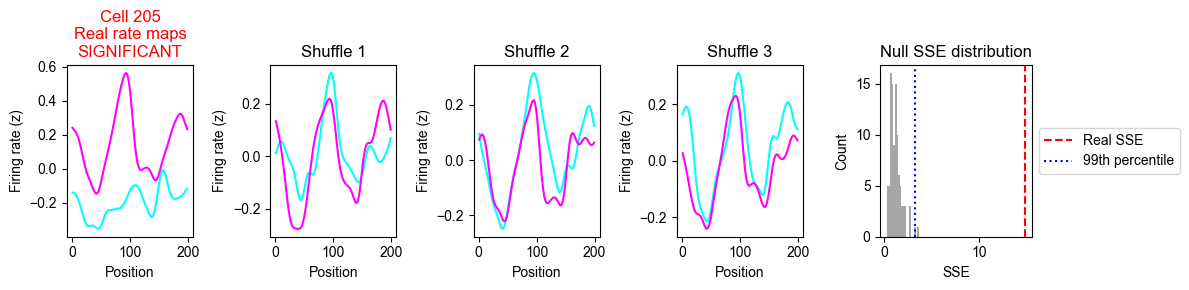

Processing cell 72/89: ID 206


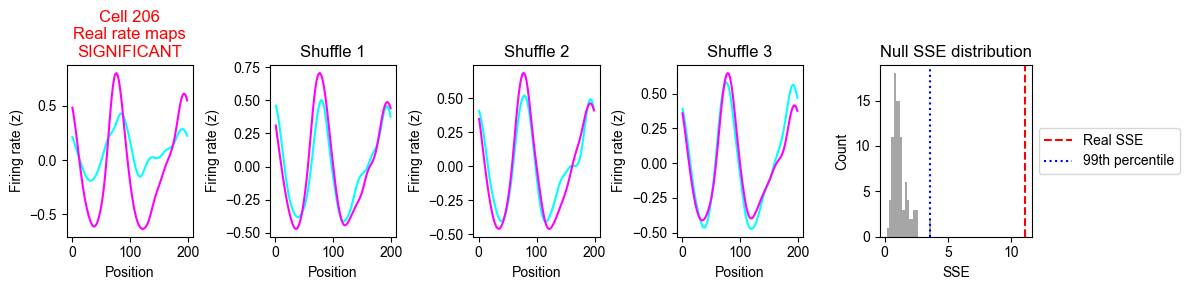

Processing cell 73/89: ID 207


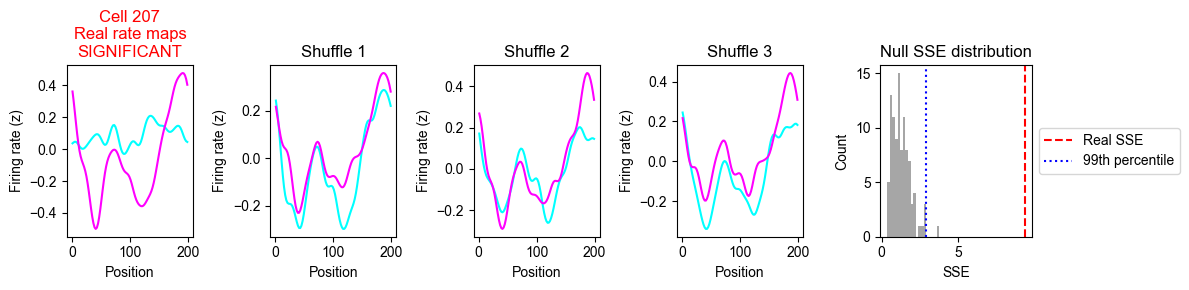

Processing cell 74/89: ID 209


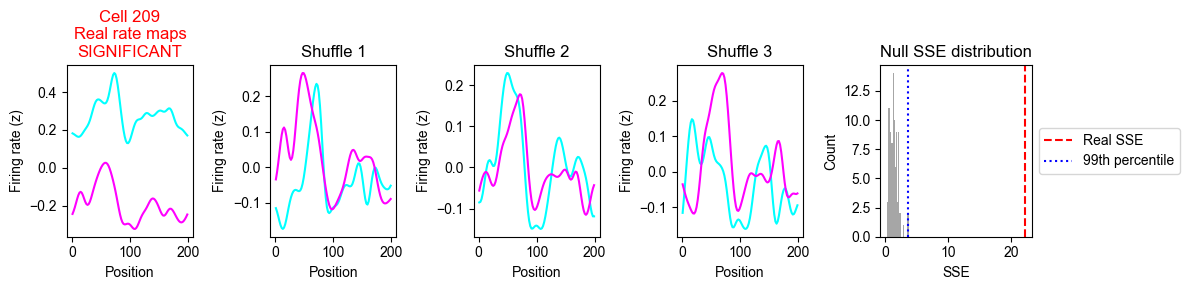

Processing cell 75/89: ID 211


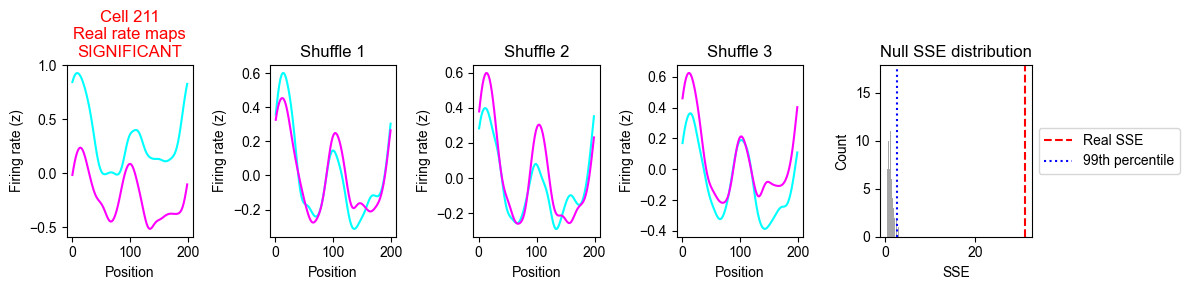

Processing cell 76/89: ID 214


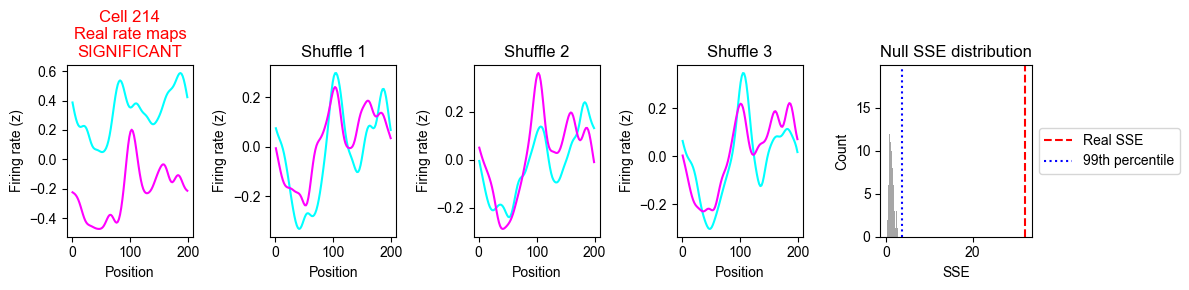

Processing cell 77/89: ID 215


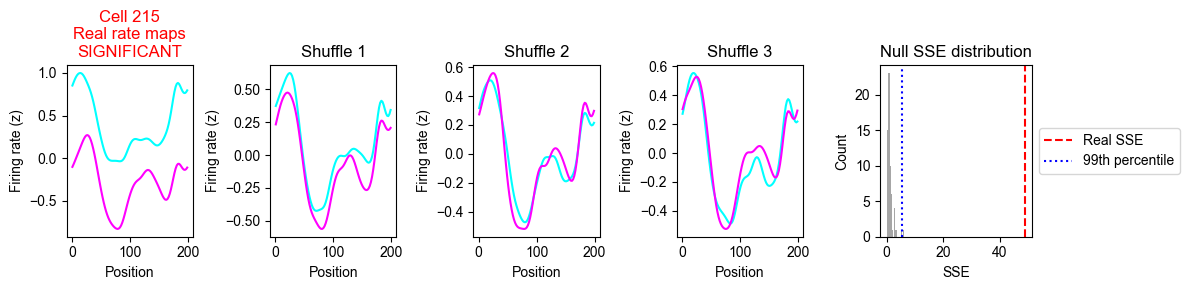

Processing cell 78/89: ID 216


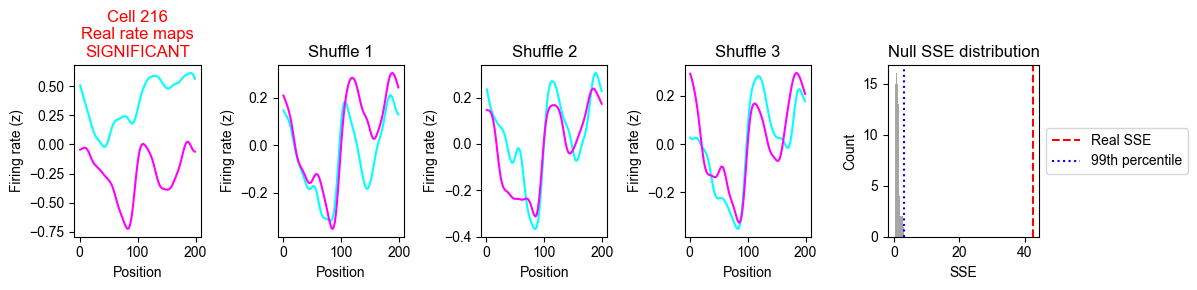

Processing cell 79/89: ID 217


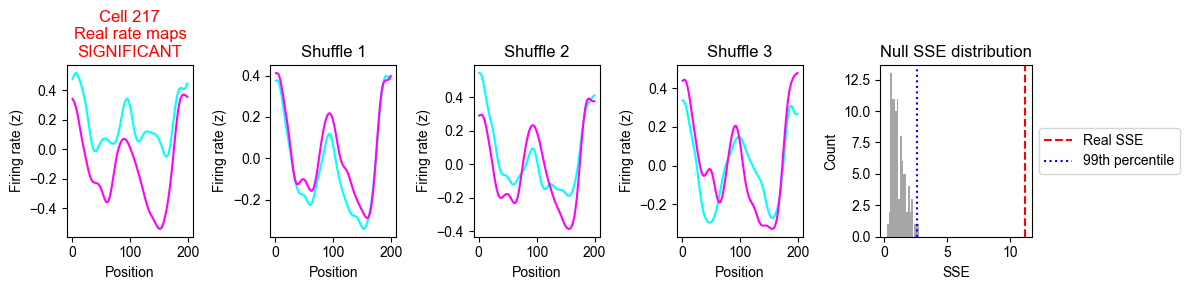

Processing cell 80/89: ID 221


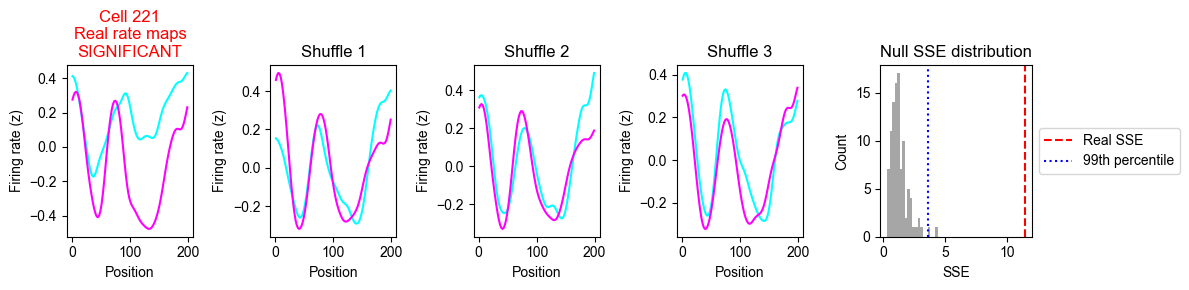

Processing cell 81/89: ID 223


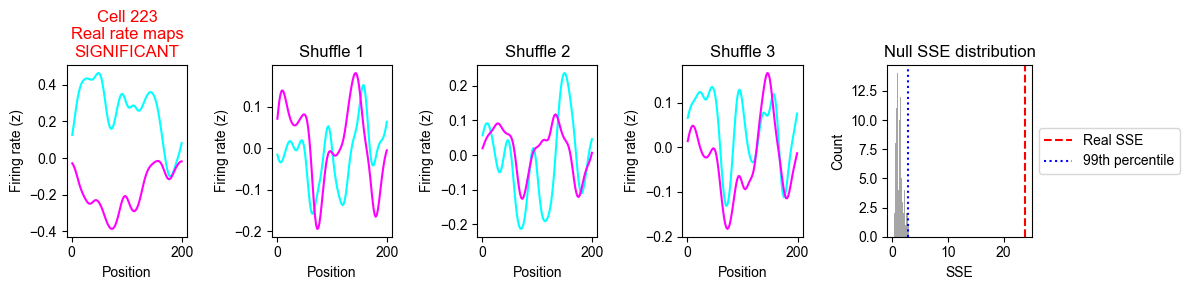

Processing cell 82/89: ID 224


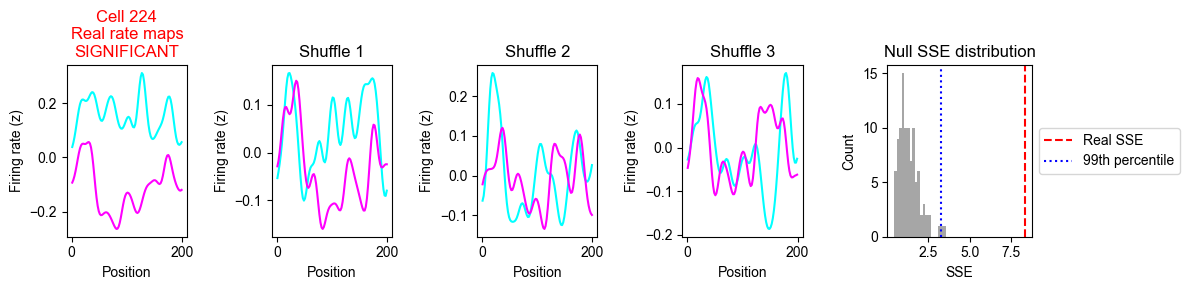

Processing cell 83/89: ID 226


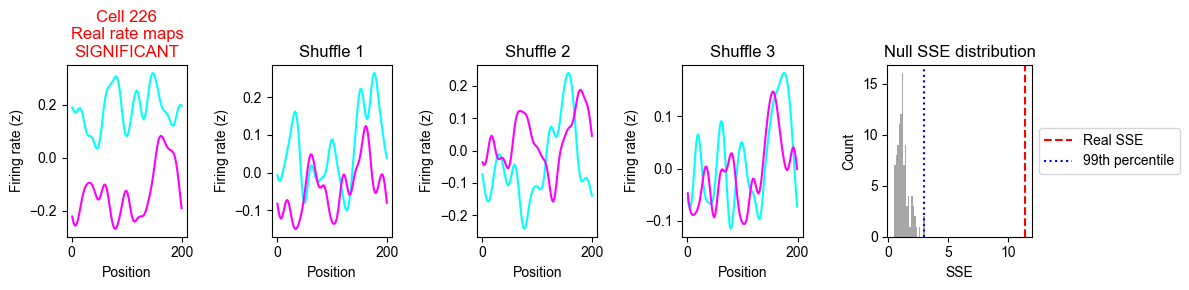

Processing cell 84/89: ID 229


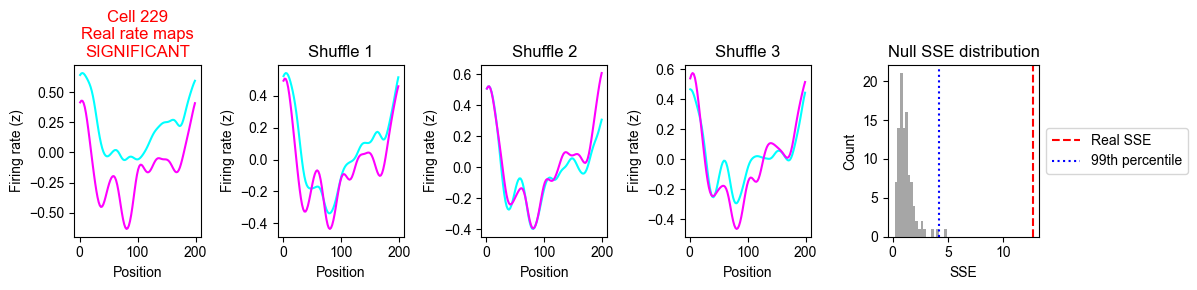

Processing cell 85/89: ID 230


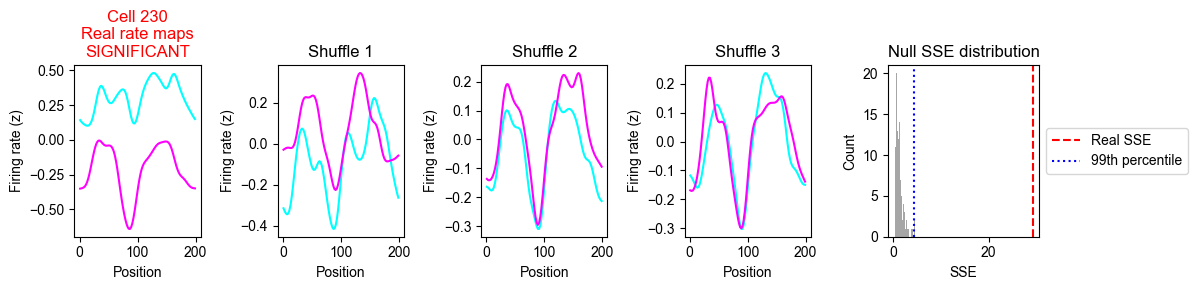

Processing cell 86/89: ID 234


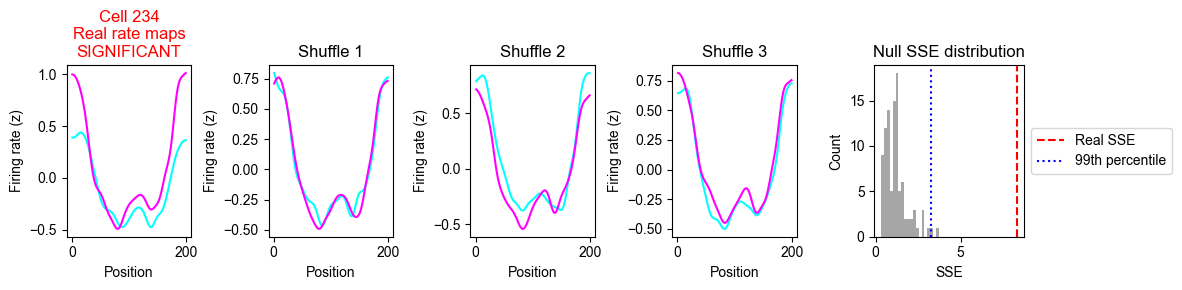

Processing cell 87/89: ID 254


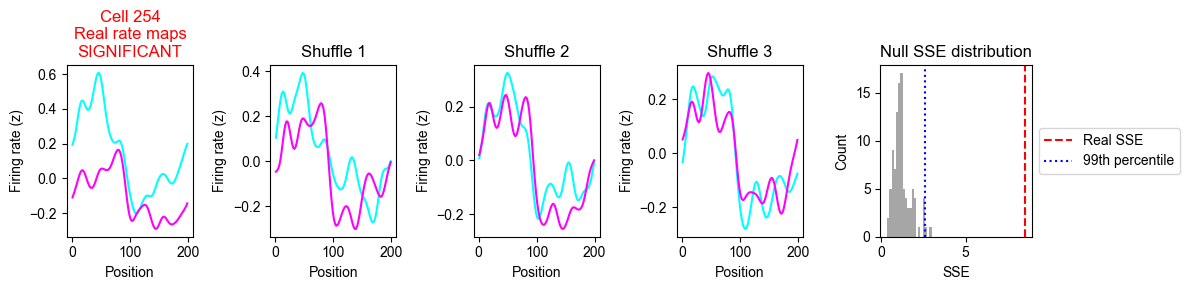

Processing cell 88/89: ID 262


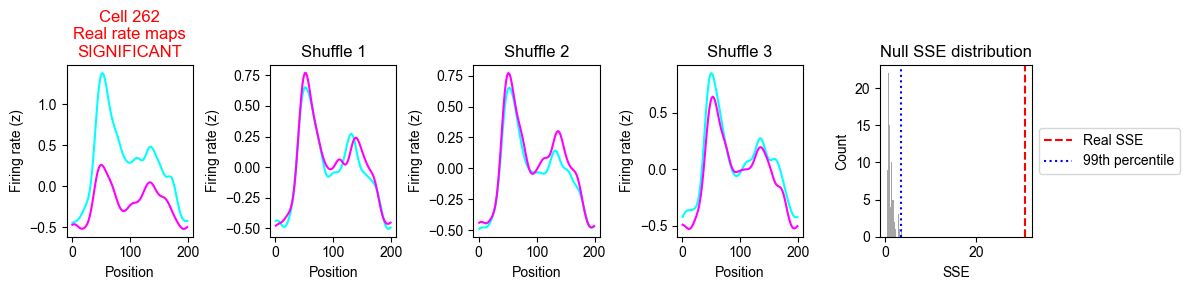

Processing cell 89/89: ID 264


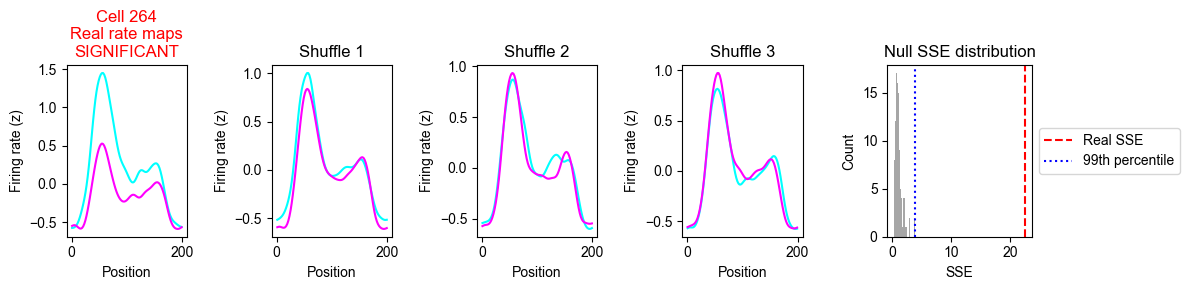

In [16]:
# For each cell, compute the sum of squared error (SSE) between task-anchored and task-independent rate maps,
# and use this as the metric instead of fold change.
import matplotlib.pyplot as plt

cluster_ids = g_m_cluster_ids[0]
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3]
S = spectrograms.mean(0)
max_peaks = np.argmax(S, axis=0)
labels = np.isin(max_peaks, peak_indices).astype(int) # using module 1 peaks as labels

sse_values = []
dists_from_mean = []
shanks = []
sig_cells = []

n_shuffles = 100  # Number of shuffles for null distribution
tcs, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day, apply_zscore=False)

n_examples = 3  # Number of shuffle examples to plot per cell

for idx, id in enumerate(all.cluster_id.values):
    print(f'Processing cell {idx+1}/{len(all.cluster_id.values)}: ID {id}')
    tc = tcs[id]
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    tc = tc[:last_ephys_bin]
    tcz = zscore(tc)
    if id == 47:
        abradradaba = tcz
    bin_config = get_bin_config('VR')
    trial_labels = get_kmeans_spatial_labels(tcz, labels, bs=bs, tl=tl)
    trials = beh['trials'][:len(trial_labels)]

    # Real rate maps
    x0, y0 = get_avg_profile(tcz, bs, tl, mask=trial_labels == 0)
    x1, y1 = get_avg_profile(tcz, bs, tl, mask=trial_labels == 1)

    # Ensure same length for SSE calculation
    min_len = min(len(y0), len(y1))
    y0 = y0[:min_len]
    y1 = y1[:min_len]
    sse_real = np.sum((y1 - y0) ** 2)
    sse_values.append(sse_real)

    # Null distribution by shuffling
    sse_shuffles = []
    shuffle_examples = []
    for shuffle_idx in range(n_shuffles):
        shuffled = np.random.permutation(trial_labels)
        x0s, y0s = get_avg_profile(tcz, bs, tl, mask=shuffled == 0)
        x1s, y1s = get_avg_profile(tcz, bs, tl, mask=shuffled == 1)
        min_len_shuf = min(len(y0s), len(y1s))
        if min_len_shuf > 0:
            y0s = y0s[:min_len_shuf]
            y1s = y1s[:min_len_shuf]
            sse_shuffles.append(np.sum((y1s - y0s) ** 2))
            if shuffle_idx < n_examples:
                shuffle_examples.append((x0s, y0s, x1s, y1s))
        else:
            sse_shuffles.append(np.nan)
    sse_shuffles = np.array(sse_shuffles)
    p99 = np.nanpercentile(sse_shuffles, 99)
    is_significant = sse_real > p99
    sig_cells.append(is_significant)

    probe_x = all[all.cluster_id == id].probe_x.values[0]
    probe_y = all[all.cluster_id == id].probe_y.values[0]
    dists_from_mean.append(np.sqrt((probe_x - mean_x) ** 2 + (probe_y - mean_y) ** 2))
    s = probe_x // 250
    shanks.append(s)

    # --- Plotting for each cell ---
    fig, axs = plt.subplots(1, 1 + n_examples + 1, figsize=(4 + 2*n_examples + 2, 3), gridspec_kw={'width_ratios': [1]*(1+n_examples)+[1.2]})

    # Real rate maps (label==0: cyan, label==1: magenta)
    axs[0].plot(x0, y0, color='cyan')
    axs[0].plot(x1, y1, color='magenta')
    sig_text = 'SIGNIFICANT' if is_significant else 'not significant'
    axs[0].set_title(f'Cell {id}\nReal rate maps\n{sig_text}', color='red' if is_significant else 'black')
    axs[0].set_xlabel('Position')
    axs[0].set_ylabel('Firing rate (z)')
    axs[0].legend().remove()

    # Shuffle examples (label==0: cyan, label==1: magenta)
    for ex_idx, (x0s, y0s, x1s, y1s) in enumerate(shuffle_examples):
        axs[1 + ex_idx].plot(x0s, y0s, color='cyan')
        axs[1 + ex_idx].plot(x1s, y1s, color='magenta')
        axs[1 + ex_idx].set_title(f'Shuffle {ex_idx+1}')
        axs[1 + ex_idx].set_xlabel('Position')
        axs[1 + ex_idx].set_ylabel('Firing rate (z)')
        axs[1 + ex_idx].legend().remove()

    # Null distribution (move legend to right)
    h = axs[-1].hist(sse_shuffles[~np.isnan(sse_shuffles)], bins=20, color='gray', alpha=0.7)
    axs[-1].axvline(sse_real, color='red', linestyle='--', label='Real SSE')
    axs[-1].axvline(p99, color='blue', linestyle=':', label='99th percentile')
    axs[-1].set_title('Null SSE distribution')
    axs[-1].set_xlabel('SSE')
    axs[-1].set_ylabel('Count')
    axs[-1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

sse_values = np.array(sse_values)
dists_from_mean = np.array(dists_from_mean)
sig_cells = np.array(sig_cells)
shanks = np.array(shanks)

In [ ]:
id=47
tc = tcs[id]
tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
tc = tc[:last_ephys_bin]
tcz = zscore(tc)
bin_config = get_bin_config('VR')
trial_labels = get_kmeans_spatial_labels(tcz, labels, bs=bs, tl=tl)
trials = beh['trials'][:len(trial_labels)]

# Real rate maps
x0, y0 = get_avg_profile(tcz, bs, tl, mask=trial_labels == 0)
x1, y1 = get_avg_profile(tcz, bs, tl, mask=trial_labels == 1)

# Ensure same length for SSE calculation
min_len = min(len(y0), len(y1))
y0 = y0[:min_len]
y1 = y1[:min_len]
sse_real = np.sum((y1 - y0) ** 2)
sse_real

np.float64(10.95649628609828)

: 

In [9]:
# For each cell, compute the sum of squared error (SSE) between task-anchored and task-independent rate maps,
# and use this as the metric instead of fold change.
cluster_ids = g_m_cluster_ids[0]
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
S = spectrograms.mean(0)
max_peaks = np.argmax(S, axis=0)
labels = np.isin(max_peaks, peak_indices).astype(int) # using module 1 peaks as labels


sse_values = []
dists_from_mean = []
shanks = []
sig_cells = []

n_shuffles = 100  # Number of shuffles for null distribution
tcs, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day, apply_zscore=False)

for idx, id in enumerate(all.cluster_id.values):
    tc = tcs[id]
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    tc = tc[:last_ephys_bin]
    tcz = zscore(tc)
    bin_config = get_bin_config('VR')
    trial_labels = get_kmeans_spatial_labels(tcz, labels, bs=bs, tl=tl)
    trials = beh['trials'][:len(trial_labels)]

    # Real rate maps
    x0, y0 = get_avg_profile(tcz, bs, tl, mask=trial_labels == 0)
    x1, y1 = get_avg_profile(tcz, bs, tl, mask=trial_labels == 1)

    # Ensure same length for SSE calculation
    min_len = min(len(y0), len(y1))
    y0 = y0[:min_len]
    y1 = y1[:min_len]
    sse_real = np.sum((y1 - y0) ** 2)
    sse_values.append(sse_real)

    # Null distribution by shuffling
    sse_shuffles = []
    for _ in range(n_shuffles):
        shuffled = np.random.permutation(trial_labels)
        x0s, y0s = get_avg_profile(tcz, bs, tl, mask=shuffled == 0)
        x1s, y1s = get_avg_profile(tcz, bs, tl, mask=shuffled == 1)
        min_len_shuf = min(len(y0s), len(y1s))
        if min_len_shuf > 0:
            y0s = y0s[:min_len_shuf]
            y1s = y1s[:min_len_shuf]
            sse_shuffles.append(np.sum((y1s - y0s) ** 2))
        else:
            sse_shuffles.append(np.nan)
    sse_shuffles = np.array(sse_shuffles)
    p99 = np.nanpercentile(sse_shuffles, 99)
    sig_cells.append(sse_real > p99)

    probe_x = all[all.cluster_id == id].probe_x.values[0]
    probe_y = all[all.cluster_id == id].probe_y.values[0]
    dists_from_mean.append(np.sqrt((probe_x - mean_x) ** 2 + (probe_y - mean_y) ** 2))
    s = probe_x // 250
    shanks.append(s)

sse_values = np.array(sse_values)
dists_from_mean = np.array(dists_from_mean)
sig_cells = np.array(sig_cells)
shanks = np.array(shanks)

Identified 1 candidate modules


In [ ]:
import matplotlib.pyplot as plt

n_examples = 3  # Number of shuffle examples to plot per cell

for idx, id in enumerate(all.cluster_id.values):
    tc = tcs[id]
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    tc = tc[:last_ephys_bin]
    tcz = zscore(tc)
    trial_labels = get_kmeans_spatial_labels(tcz, labels, bs=bs, tl=tl)

    # Real rate maps
    x0, y0 = get_avg_profile(tcz, bs, tl, mask=trial_labels == 0)
    x1, y1 = get_avg_profile(tcz, bs, tl, mask=trial_labels == 1)
    min_len = min(len(y0), len(y1))
    y0 = y0[:min_len]
    y1 = y1[:min_len]
    sse_real = np.sum((y1 - y0) ** 2)

    # Null distribution by shuffling
    sse_shuffles = []
    shuffle_examples = []
    for shuffle_idx in range(n_shuffles):
        shuffled = np.random.permutation(trial_labels)
        x0s, y0s = get_avg_profile(tcz, bs, tl, mask=shuffled == 0)
        x1s, y1s = get_avg_profile(tcz, bs, tl, mask=shuffled == 1)
        min_len_shuf = min(len(y0s), len(y1s))
        if min_len_shuf > 0:
            y0s = y0s[:min_len_shuf]
            y1s = y1s[:min_len_shuf]
            sse_shuffles.append(np.sum((y1s - y0s) ** 2))
            if shuffle_idx < n_examples:
                shuffle_examples.append((x0s, y0s, x1s, y1s))
        else:
            sse_shuffles.append(np.nan)
    sse_shuffles = np.array(sse_shuffles)
    p99 = np.nanpercentile(sse_shuffles, 99)
    is_significant = sse_real > p99

    # Plot for this cell
    fig, axs = plt.subplots(1, 2 + n_examples, figsize=(4 + 2*n_examples, 3))
    # Real rate maps
    axs[0].plot(x0, y0, label='Real label 0')
    axs[0].plot(x1, y1, label='Real label 1')
    sig_text = 'SIGNIFICANT' if is_significant else 'not significant'
    axs[0].set_title(f'Cell {id}\nReal rate maps\n{sig_text}', color='red' if is_significant else 'black')
    axs[0].set_xlabel('Position')
    axs[0].set_ylabel('Firing rate (z)')
    axs[0].legend()

    # Null distribution
    axs[1].hist(sse_shuffles[~np.isnan(sse_shuffles)], bins=20, color='gray', alpha=0.7)
    axs[1].axvline(sse_real, color='red', linestyle='--', label='Real SSE')
    axs[1].axvline(p99, color='blue', linestyle=':', label='99th percentile')
    axs[1].set_title('Null SSE distribution')
    axs[1].set_xlabel('SSE')
    axs[1].set_ylabel('Count')
    axs[1].legend()

    # Shuffle examples
    for ex_idx, (x0s, y0s, x1s, y1s) in enumerate(shuffle_examples):
        axs[2 + ex_idx].plot(x0s, y0s, label='Shuffle label 0')
        axs[2 + ex_idx].plot(x1s, y1s, label='Shuffle label 1')
        axs[2 + ex_idx].set_title(f'Shuffle {ex_idx+1}')
        axs[2 + ex_idx].set_xlabel('Position')
        axs[2 + ex_idx].set_ylabel('Firing rate (z)')
        axs[2 + ex_idx].legend()

    plt.tight_layout()
    plt.show()

Module 1: 8 significant / 8 total (1.00 proportion)
Module 2: 4 significant / 5 total (0.80 proportion)
NGS: 61 significant / 61 total (1.00 proportion)


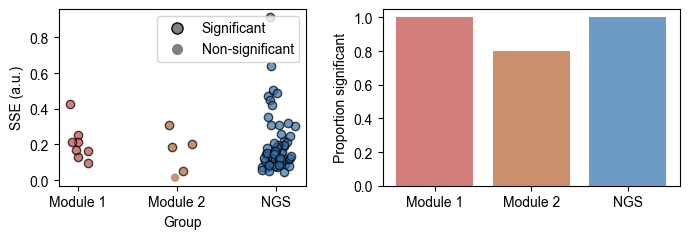

In [14]:
from matplotlib.lines import Line2D

# Define groups: module 1, 2, 3, and NGS
group_cluster_ids = [
    g_m_cluster_ids[0],  # Module 1
    g_m_cluster_ids[1],  # Module 2
    ngs.cluster_id.values  # NGS
]
group_labels = ['Module 1', 'Module 2', 'NGS']
colors = ["#c04744", "#B6632F", "#3171ae"]

n_sig = []
n_total = []
proportion = []
group_sse = []
group_sig_cells = []

for i, cluster_ids in enumerate(group_cluster_ids):
    mask = np.isin(all.cluster_id.values, cluster_ids)
    n_sig.append(np.sum(sig_cells[mask]))
    n_total.append(np.sum(mask))
    group_sse.append(sse_values[mask])
    group_sig_cells.append(sig_cells[mask])
    if n_total[-1] > 0:
        proportion.append(n_sig[-1] / n_total[-1])
    else:
        proportion.append(np.nan)

# Print summary
for i, label in enumerate(group_labels):
    print(f"{label}: {n_sig[i]} significant / {n_total[i]} total ({proportion[i]:.2f} proportion)")

# Create the figure and axes for the merged plots
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(7, 2.5), gridspec_kw={'width_ratios': [1, 1.2]})

# Bar plot (left)
ax1.bar(group_labels, proportion, color=colors, alpha=0.7)
ax1.set_ylabel('Proportion significant')
ax1.set_ylim(0, 1.05)

# Jitter plot (right)
for i in range(3):
    y = group_sse[i]
    sig = group_sig_cells[i]
    x = np.random.normal(i, 0.08, size=len(y))  # jitter
    ax2.scatter(x[sig], y[sig]/(tl/bs), color=colors[i], alpha=0.7, edgecolor='black', label=None if i else 'Significant')
    ax2.scatter(x[~sig], y[~sig]/(tl/bs), color=colors[i], alpha=0.7, edgecolor='none', label=None if i else 'Non-significant')

# Custom legend for sig/non-sig
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='black', label='Significant', markersize=8),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='none', label='Non-significant', markersize=8)
]
ax2.legend(handles=legend_elements, loc='upper right')

ax2.set_xticks(range(3))
ax2.set_xticklabels(group_labels)
ax2.set_ylabel('SSE (a.u.)')
ax2.set_xlabel('Group')

plt.tight_layout(w_pad=2)
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/M{mouse}D{day}_modules_ngs_sse_and_proportion.pdf', dpi=300)
plt.show()

In [ ]:
for m in range(len(g_m_cluster_ids)):
    plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day,
                                                           cluster_ids_for_spectrogram=g_m_cluster_ids[0],
                                                           cluster_ids=g_m_cluster_ids[m], 
                                                           label=f'_module{m}_', 
                                                           figpath='/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/')
plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day,
                                                           cluster_ids_for_spectrogram=g_m_cluster_ids[0],
                                                           cluster_ids=ngs.cluster_id.values, 
                                                           label=f'ngs_', 
                                                           figpath='/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/')


In [ ]:
bs_t=100
tcs, tcs_time, autocorrs, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse, day, bs_t=bs_t)
speed_in_time, dt_in_time, pos_in_time, trial_number_in_time, trial_type_in_time = get_time_binned_variables(mouse, day, bs_t=bs_t)

cluster_ids = []
cluster_ids.extend(g_m_cluster_ids[0]) # grid cells by module [0,1,2...]
cluster_ids.extend(g_m_cluster_ids[1]) # grid cells by module [0,1,2...]
cluster_ids.extend(g_m_cluster_ids[2]) # grid cells by module [0,1,2...]
#cluster_ids.extend(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
#cluster_ids = all_by_anatomy['cluster_id'].values.tolist() # all cells
 
# decoding in time
clusters_tcs_time = {cluster_id: tcs_time[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs_time}
print(f'Number of clusters to decode: {len(clusters_tcs_time)}')

pos_in_time = np.array(pos_in_time) 
trial_number_in_time = np.array(trial_number_in_time)
dt_in_time = np.array(dt_in_time)
tns_to_decode_with = np.array(beh['trials']['number'])
tns_to_decode_with = tns_to_decode_with[tns_to_decode_with<=np.nanmax(trial_number_in_time)]
trial_types = np.array(beh['trials']['type'])

tns_to_decode = np.array(beh['trials']['number']) # decode all trials to visualise
tns_to_train = np.array(beh['trials']['number'][(np.isin(beh['trials']['type'], np.array(['b','nb']))) &
                                                (np.isin(beh['trials']['performance'], np.array(['hit'])))]) 
tns_to_train = np.array(beh['trials']['number'][(np.isin(beh['trials']['type'], np.array(['b','nb'])))]) 
tns_to_decode = tns_to_decode[tns_to_decode<=np.nanmax(trial_number_in_time)] # handles last ephys trials
tns_to_train = tns_to_train[tns_to_train<=np.nanmax(trial_number_in_time)] # handles last ephys trials

predictions_in_time, errors_in_time = cross_validate_decoder_time(clusters_tcs_time, 
                                                true_position=pos_in_time, 
                                                trial_numbers=trial_number_in_time, 
                                                tns_to_decode=tns_to_decode, 
                                                tns_to_train=tns_to_train, 
                                                tl=tl, bs=bs, train=0.9, n=10, verbose=False)

avg_predictions_in_time = [np.mean(np.stack(preds_n), axis=0) for preds_n in predictions_in_time]
avg_predictions_in_time = np.concatenate(avg_predictions_in_time).ravel()
avg_errors_in_time = [np.mean(np.stack(errors_n), axis=0) for errors_n in errors_in_time]
avg_errors_in_time = np.concatenate(avg_errors_in_time).ravel()

In [ ]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# --- Top row: True vs Predicted Position ---
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 3), sharex=True, height_ratios=[1, 0.4])

# Time axis (in seconds)
time_axis = np.arange(len(pos_in_time))*(bs_t/1000)/60

def break_large_jumps(arr, threshold):
    arr = np.array(arr)
    diffs = np.abs(np.diff(arr))
    # Find indices where the jump exceeds the threshold
    jump_idx = np.where(diffs > threshold)[0] + 1
    arr_plot = arr.astype(float).copy()
    arr_plot[jump_idx] = np.nan
    return arr_plot

# --- Decoding Error: raw and smooth ---
smooth_error = gaussian_filter1d(avg_errors_in_time, sigma=40)
ax[0].plot(time_axis, avg_errors_in_time, label='Prediction Error (raw)', color='grey', alpha=0.3, linewidth=1)
ax[0].plot(time_axis, smooth_error, label='Prediction Error (smoothed)', color='black', linewidth=1)
ax[0].set_ylabel('Decoding error (cm)')
ax[0].set_ylim(0,60)

peak_indices = [12, 28, 44, 60, 76]

for m in range(len(g_m_cluster_ids)):
    cluster_ids = g_m_cluster_ids[m]
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    fvalid = results[5]
    S = spectrograms.mean(0)
    max_peaks = np.argmax(S, axis=0)
    labels = np.isin(max_peaks, peak_indices).astype(int)

    tc = tcs[g_m_cluster_ids[0][0]]
    tc = tc[:last_ephys_bin] # only want bins with ephys data in it
    trial_labels = get_kmeans_spatial_labels(tc, labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring
    # get time binned labels
    labels_in_time = trial_number_in_time.copy()
    for label, tn in zip(trial_labels, np.unique(trial_number_in_time)):
        labels_in_time[trial_number_in_time == tn] = label
    
    ax[-1].scatter(time_axis, np.ones(len(labels_in_time))*m, 
                   c=labels_in_time, cmap='cool', marker='s', s=50, vmin=0, vmax=1, edgecolor='none',clip_on=True)
    
    ax[-1].spines['top'].set_visible(False)
    ax[-1].spines['left'].set_visible(False)
    ax[-1].spines['bottom'].set_visible(False)
    ax[-1].spines['right'].set_visible(False)
    ax[-1].set_ylim(-3.5,2.5)
    ax[-1].set_yticks([])
    ax[-1].set_xticks([])



performance = np.array(beh['trials']['performance'])
trial_types = np.array(beh['trials']['type'])
trial_numbers = np.array(beh['trials']['number'])

# make performance in time
b_performance_in_time = np.zeros(len(pos_in_time)); b_performance_in_time[:] = np.nan
nb_performance_in_time = np.zeros(len(pos_in_time)); nb_performance_in_time[:] = np.nan
for i, tn in enumerate(trial_number_in_time):
    if tn in trial_numbers[(trial_types == 'b') & (performance == 'hit')]:
        b_performance_in_time[i] = 1
    elif tn in trial_numbers[(trial_types == 'nb') & (performance == 'hit')]:
        nb_performance_in_time[i] = 1


# make performance in time
b_performance_in_time = np.zeros(len(pos_in_time)); b_performance_in_time[:] = np.nan
nb_performance_in_time = np.zeros(len(pos_in_time)); nb_performance_in_time[:] = np.nan
b_streak = 0
nb_streak = 0
for i, tn in enumerate(trial_number_in_time):
    if tn in trial_numbers[(trial_types == 'b') & (performance == 'hit')]:
        b_streak += 1
    elif tn in trial_numbers[(trial_types == 'nb') & (performance == 'hit')]:
        nb_streak += 1
    elif tn in trial_numbers[(trial_types == 'b') & (performance != 'hit')]:
        b_streak = 0
    elif tn in trial_numbers[(trial_types == 'nb') & (performance != 'hit')]:
        nb_streak = 0
    if b_streak >= 150:
        b_performance_in_time[i] = 1
    if nb_streak >= 150:
        nb_performance_in_time[i] = 1
ax[-1].scatter(time_axis, np.ones(len(b_performance_in_time)) -3, 
               c=b_performance_in_time, cmap='winter', marker='|', s=50, vmin=0, vmax=1, edgecolor='none',clip_on=True)
ax[-1].scatter(time_axis, np.ones(len(nb_performance_in_time)) -4, 
               c=nb_performance_in_time, cmap='winter', marker='|', s=50, vmin=0, vmax=1, edgecolor='none',clip_on=True)

ax[0].set_xlim(18.5,22)
ax[0].set_xlim(0, 30)
plt.tight_layout()
fig.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/M{mouse}D{day}_decoding_error.pdf', bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

for tt in ['b', 'nb']:
    # --- Top row: True vs Predicted Position ---
    fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 6), sharex=True)

    # Time axis (in seconds)
    time_axis = np.arange(len(pos_in_time[trial_type_in_time==tt]))*(bs_t/1000)/60

    ax[0].plot(time_axis, pos_in_time[trial_type_in_time==tt], label='True Position', color='black', linewidth=1)
    ax[0].plot(time_axis, avg_predictions_in_time[trial_type_in_time==tt], label='Predicted Position', color='red', alpha=0.7, linewidth=1)
    ax[0].set_ylabel('Position')
    ax[0].set_title('True vs Predicted Position Over Time')
    ax[0].legend()

    # --- Decoding Error: raw and smooth ---
    smooth_error = gaussian_filter1d(avg_errors_in_time, sigma=10)
    ax[1].plot(time_axis, avg_errors_in_time[trial_type_in_time==tt], label='Prediction Error (raw)', color='grey', alpha=0.5, linewidth=1)
    ax[1].plot(time_axis, smooth_error[trial_type_in_time==tt], label='Prediction Error (smoothed)', color='black', linewidth=2)
    ax[1].set_ylabel('Error')
    ax[1].legend()
    ax[1].set_ylim(0,60)
    plt.tight_layout()
    plt.show()

In [ ]:
cluster_ids = []
cluster_ids.extend(g_m_cluster_ids[0]) # grid cells by module [0,1,2...]
cluster_ids.extend(g_m_cluster_ids[1]) # grid cells by module [0,1,2...]
cluster_ids.extend(g_m_cluster_ids[2]) # grid cells by module [0,1,2...]
#cluster_ids.extend(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
plot_decoding(mouse, day, cluster_ids=cluster_ids, label='all_cells', 
              figpath='/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/')

plot the spectrograms and the maximal frequency at each time point

In [ ]:
group_names = ['GM' + str(i+1) for i in range(len(g_m_cluster_ids))] + ['NGS']
group_labels = []
group_spectrograms = []
for m in range(len(g_m_cluster_ids)):
    cluster_ids = g_m_cluster_ids[m]
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3]
    fvalid = results[5]

    S = spectrograms.mean(0)
    kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
    labels = kmeans.fit_predict(S.T)
    group_labels.append(labels)
    group_spectrograms.append(S)
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
S = spectrograms.mean(0)
kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
labels = kmeans.fit_predict(S.T)
group_labels.append(labels)
group_spectrograms.append(S)

# calculate agreement between groups
agreements = np.zeros((len(group_spectrograms), len(group_spectrograms)))
for i, m in enumerate(range(len(group_spectrograms))):
    for j, n in enumerate(range(len(group_spectrograms))):
        agreements[i, j] = np.sum(group_labels[i] == group_labels[j]) / len(group_labels[i])

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 3), squeeze=False)

ax[0,0].imshow(agreements, cmap='viridis', vmin=0, vmax=1)
# offset the x and y ticks to be the group names
ax[0,0].set_xticks(np.arange(len(group_names)))
ax[0,0].set_yticks(np.arange(len(group_names)))
ax[0,0].set_xticklabels(group_names)
ax[0,0].set_yticklabels(group_names)
ax[0,0].set_xlabel('Cell group')
ax[0,0].set_ylabel('Cell group')

ax[0,0].set_title('Agreement between groups')   
# add agreeement values to the cells
for i in range(len(group_names)):
    for j in range(len(group_names)):
        ax[0,0].text(j, i, f'{agreements[i, j]:.2f}', ha='center', va='center', color='black', fontsize=8)
plt.tight_layout()    
plt.show()

In [ ]:
for m, cluster_ids in enumerate(g_m_cluster_ids):
    plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=cluster_ids, label=f'_module{m}_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_grid_module/')
    plot_individual_rate_maps_with_avg_k_means_grouped_spectrogram(mouse, day, cluster_ids=cluster_ids, label=f'_module{m}_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_grid_module/')
    plot_individual_rate_maps_with_avg(mouse, day, cluster_ids=cluster_ids, label=f'_module{m}_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_grid_module/')
plot_individual_rate_maps_with_avg_k_means_grouped_spectrogram(mouse, day, cluster_ids=ngs.cluster_id.values, label=f'_NGS_', figpath='/Users/harryclark/Documents/figs/rate_maps_by_grid_module/')


In [ ]:
def get_task_anchored_labels_in_time(mouse, day, cluster_ids_for_spectrogram):
    tcs, tcs_time, autocorrs, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse, day, apply_zscore=False) # recompute tcs without z-scoring to use in the spectrogram
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids_for_spectrogram if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    S = spectrograms.mean(0)
    max_peaks = np.argmax(S, axis=0)
    labels = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int) # these are the peaks that correspond to the task anchoring
    trial_labels = get_kmeans_spatial_labels(tcs[cluster_ids_for_spectrogram[0]], labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring

    last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

    # time binned variables for later
    ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
    speed_in_time = beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)
    dt_in_time = beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl)
    time_vals = np.arange(0, len(speed_in_time)*(time_bs/1000),time_bs/1000) # secs
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

    trial_number_in_time = pd.Series(np.array(trial_number_in_time)).fillna(method='ffill').fillna(method='bfill').to_numpy()
    trial_labels_trial_numbers = np.arange(trial_number_in_time[0], len(trial_labels)+trial_number_in_time[0], 1)
    trial_labels_in_time = np.zeros(len(trial_number_in_time), dtype=int)
    assert len(trial_labels) == len(trial_labels_trial_numbers), f'len(trial_labels)={len(trial_labels)} != len(trial_labels_trial_numbers)={len(trial_labels_trial_numbers)}'

    for i, tn in enumerate(trial_number_in_time.astype(int)):
        trial_labels_in_time[i] = trial_labels[np.where(trial_labels_trial_numbers == tn)[0][0]].astype(int)
    
    return trial_labels_in_time



In [ ]:
# we want to compare the firing rate changes between task anchoring and task independent firing according to grid module 1
cluster_ids_for_spectrogram = g_m_cluster_ids[0] # use the first grid module for the spectrogram

tcs, tcs_time, autocorrs, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse, day, apply_zscore=False) # recompute tcs without z-scoring to use in the spectrogram
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids_for_spectrogram if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
S = spectrograms.mean(0)
max_peaks = np.argmax(S, axis=0)
labels = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int) # these are the peaks that correspond to the task anchoring
trial_labels = get_kmeans_spatial_labels(tcs[cluster_ids_for_spectrogram[0]], labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring

last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

# time binned variables for later
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
speed_in_time = beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)
dt_in_time = beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl)
time_vals = np.arange(0, len(speed_in_time)*(time_bs/1000),time_bs/1000) # secs
pos_in_time = dt_in_time%tl
trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

trial_number_in_time = pd.Series(np.array(trial_number_in_time)).fillna(method='ffill').fillna(method='bfill').to_numpy()
trial_labels_trial_numbers = np.arange(trial_number_in_time[0], len(trial_labels)+trial_number_in_time[0], 1)
trial_labels_in_time = np.zeros(len(trial_number_in_time), dtype=int)
assert len(trial_labels) == len(trial_labels_trial_numbers), f'len(trial_labels)={len(trial_labels)} != len(trial_labels_trial_numbers)={len(trial_labels_trial_numbers)}'

for i, tn in enumerate(trial_number_in_time.astype(int)):
    trial_labels_in_time[i] = trial_labels[np.where(trial_labels_trial_numbers == tn)[0][0]].astype(int)


